# Setup

In [3]:
!pip install SciencePlots
!pip install latex

import platform
if platform.system() == "Linux":
    import subprocess
    subprocess.run(["sudo", "apt-get", "update", "-y"], check=False)
    subprocess.run(["sudo", "apt-get", "install", "-y",
                    "dvipng", "texlive-latex-extra",
                    "texlive-fonts-recommended", "cm-super"], check=False)

In [4]:
import itertools
import pandas as pd
import matplotlib.ticker as ticker
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

# Base Example

In [5]:

# ---------------------------------------------------------
# 1. Define Network Parameters
# ---------------------------------------------------------
cost_dc = 4.0      # Investment cost per facility
cost_op = 0.5      # Operational/transport cost per unit
cost_pen = 2.5     # Recourse penalty for unmet demand
cap_dc = 4.0       # Capacity of one DC

cities = ['a', 'b', 'c']

# Demand realizations for each city
demands = {
    'a': [1, 3],
    'b': [1, 4],
    'c': [1, 5]
}

# Cost of Gathering Information (CGI) per city
cgis = {
    'a': 0.15,
    'b': 0.15,
    'c': 0.45
}

# ---------------------------------------------------------
# 2. Generate the Scenario Space
# ---------------------------------------------------------
scenarios = []
# 2^3 = 8 scenarios, each with an equal probability of 0.125
for da, db, dc in itertools.product(demands['a'], demands['b'], demands['c']):
    scenarios.append({
        'a': da,
        'b': db,
        'c': dc,
        'prob': 0.125,
        'total_demand': da + db + dc
    })
df_scen = pd.DataFrame(scenarios)

# ---------------------------------------------------------
# 3. Define the Cost Function
# ---------------------------------------------------------
# Since all operational costs are equal, the strategic decision simplifies
# to choosing the optimal NUMBER of distribution centers (1, 2, or 3).
def calc_cost(total_demand, num_dcs):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (cost_dc * num_dcs) + (cost_op * fulfilled) + (cost_pen * unmet)

# Pre-calculate the cost of opening 1, 2, or 3 DCs for every scenario
df_scen['cost_1dc'] = df_scen['total_demand'].apply(lambda d: calc_cost(d, 1))
df_scen['cost_2dc'] = df_scen['total_demand'].apply(lambda d: calc_cost(d, 2))
df_scen['cost_3dc'] = df_scen['total_demand'].apply(lambda d: calc_cost(d, 3))

# ---------------------------------------------------------
# 4. Evaluate Wait-and-See for an IGS phi (WS(phi))
# ---------------------------------------------------------
def evaluate_ws(phi):
    """
    Evaluates the Wait-and-See cost given an information strategy phi.
    phi is a list of cities we survey, e.g., ['b', 'c']
    """
    if not phi:
        # If no information is gathered, we make one static decision based on expected costs
        ec_1 = (df_scen['prob'] * df_scen['cost_1dc']).sum()
        ec_2 = (df_scen['prob'] * df_scen['cost_2dc']).sum()
        ec_3 = (df_scen['prob'] * df_scen['cost_3dc']).sum()
        return min(ec_1, ec_2, ec_3)

    ws_phi = 0.0
    # Group scenarios by the realizations of the surveyed cities
    grouped = df_scen.groupby(list(phi))

    for _, group in grouped:
        group_prob = group['prob'].sum()

        # Calculate the conditional expected cost for each DC choice
        ec_1 = (group['prob'] * group['cost_1dc']).sum() / group_prob
        ec_2 = (group['prob'] * group['cost_2dc']).sum() / group_prob
        ec_3 = (group['prob'] * group['cost_3dc']).sum() / group_prob

        # Pick the best strategic decision for this specific information realization
        best_decision_ec = min(ec_1, ec_2, ec_3)

        # Add the probability-weighted cost back to the total Expected Cost
        ws_phi += group_prob * best_decision_ec

    return ws_phi

# ---------------------------------------------------------
# 5. Compute Metrics for All Subsets (The Power Set)
# ---------------------------------------------------------
all_subsets = []
for L in range(len(cities) + 1):
    for subset in itertools.combinations(cities, L):
        all_subsets.append(list(subset))

# The Recourse Problem (WS with no information)
ws_empty = evaluate_ws([])

results = []
for phi in all_subsets:
    ws = evaluate_ws(phi)
    evppi = ws_empty - ws
    cgi = sum(cgis[c] for c in phi)
    etsci = ws + cgi

    phi_str = "{" + ",".join(phi) + "}" if phi else "{}"

    results.append({
        'phi': phi_str,
        'EVPPI(phi)': evppi,
        'CGI(phi)': cgi,
        'WS(phi)': ws,
        'ETSCI(phi)': etsci
    })

# ---------------------------------------------------------
# 6. Format and Display Results
# ---------------------------------------------------------
df_results = pd.DataFrame(results)

# Reorder to match Table 2 formatting (Sizes descending, then alphabetically)
custom_order = ["{a,b,c}", "{a,b}", "{a,c}", "{b,c}", "{a}", "{b}", "{c}", "{}"]
df_results['phi'] = pd.Categorical(df_results['phi'], categories=custom_order, ordered=True)
df_results = df_results.sort_values('phi').reset_index(drop=True)

print("Determining Optimal IGS for the SCND Example:")
print("-" * 65)
print(df_results.to_string(index=False))
print("-" * 65)

# Identify the optimal strategy
optimal_row = df_results.loc[df_results['ETSCI(phi)'].idxmin()]
print(f"\nOptimal IGS (phi*): {optimal_row['phi']}")
print(f"Minimum ETSCI:      {optimal_row['ETSCI(phi)']}")

Determining Optimal IGS for the SCND Example:
-----------------------------------------------------------------
    phi  EVPPI(phi)  CGI(phi)  WS(phi)  ETSCI(phi)
{a,b,c}        1.25      0.75    12.25       13.00
  {a,b}        0.25      0.30    13.25       13.55
  {a,c}        0.75      0.60    12.75       13.35
  {b,c}        1.25      0.60    12.25       12.85
    {a}        0.00      0.15    13.50       13.65
    {b}        0.00      0.15    13.50       13.65
    {c}        0.25      0.45    13.25       13.70
     {}        0.00      0.00    13.50       13.50
-----------------------------------------------------------------

Optimal IGS (phi*): {b,c}
Minimum ETSCI:      12.85


# Proofs of Proposition 1 Points 1-6

In [6]:
import itertools
import pandas as pd
import numpy as np

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5

def calc_cost(total_demand, num_dcs, cap_dc):
    """Calculates the total cost for a given demand and number of DCs."""
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def build_independent_scenarios(d_a, d_b, d_c):
    """Builds a scenario space assuming independent probabilities."""
    scenarios = []
    for a, b, c in itertools.product(d_a, d_b, d_c):
        scenarios.append({'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a + b + c})
    return pd.DataFrame(scenarios)

def evaluate_ws(phi, df_scen, allowed_dcs=[1, 2, 3], cap_dc=4.0):
    """Evaluates the Wait-and-See (WS) cost for a given Information Gathering Strategy (phi)."""
    if not phi:
        costs = []
        for dcs in allowed_dcs:
            c = (df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum()
            costs.append(c)
        return min(costs)

    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        costs = []
        for dcs in allowed_dcs:
            c = (group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum() / group_prob
            costs.append(c)
        ws_phi += group_prob * min(costs)
    return ws_phi

# =============================================================================
# 2. Verification of Proposition 1
# =============================================================================

print("VERIFYING PROPOSITION 1")
print("="*60)

# --- Point 1: Monotonicity and Non-Submodularity ---
print("\n--- Point 1: Non-Submodularity ---")
df_base = build_independent_scenarios([1, 3], [1, 4], [1, 5])

ws_c = evaluate_ws(['c'], df_base)
ws_ac = evaluate_ws(['a', 'c'], df_base)
ws_bc = evaluate_ws(['b', 'c'], df_base)
ws_abc = evaluate_ws(['a', 'b', 'c'], df_base)

diff_ac_c = ws_ac - ws_c
diff_abc_bc = ws_abc - ws_bc

print(f"WS({{a,c}}) - WS({{c}}) = {ws_ac} - {ws_c} = {diff_ac_c}")
print(f"WS({{a,b,c}}) - WS({{b,c}}) = {ws_abc} - {ws_bc} = {diff_abc_bc}")
print(f"Submodularity Violated: {diff_ac_c} < {diff_abc_bc} -> {diff_ac_c < diff_abc_bc}")

# --- Point 2: Non-Additivity (Superadditive vs Subadditive) ---
print("\n--- Point 2: Non-Additivity ---")
ws_empty_base = evaluate_ws([], df_base)
evppi_a = ws_empty_base - evaluate_ws(['a'], df_base)
evppi_b = ws_empty_base - evaluate_ws(['b'], df_base)
evppi_c = ws_empty_base - evaluate_ws(['c'], df_base)
evppi_abc = ws_empty_base - ws_abc

sum_indiv = evppi_a + evppi_b + evppi_c
print(f"Base Case (db=[1,4]): EVPPI(G) = {evppi_abc}, Sum of EVPPI(i) = {sum_indiv}")
print(f"Is Superadditive? {evppi_abc >= sum_indiv}")

# Subadditive Case (Change db2 to 2)
df_sub = build_independent_scenarios([1, 3], [1, 2], [1, 5])
ws_empty_sub = evaluate_ws([], df_sub)
evppi_a_sub = ws_empty_sub - evaluate_ws(['a'], df_sub)
evppi_b_sub = ws_empty_sub - evaluate_ws(['b'], df_sub)
evppi_c_sub = ws_empty_sub - evaluate_ws(['c'], df_sub)
evppi_abc_sub = ws_empty_sub - evaluate_ws(['a', 'b', 'c'], df_sub)

sum_indiv_sub = evppi_a_sub + evppi_b_sub + evppi_c_sub
print(f"New Case  (db=[1,2]): EVPPI(G) = {evppi_abc_sub}, Sum of EVPPI(i) = {sum_indiv_sub}")
print(f"Is Subadditive? {evppi_abc_sub <= sum_indiv_sub}")

# --- Point 3: Not (alpha, beta)-weakly DR-modular ---
print("\n--- Point 3: Not (alpha, beta)-weakly DR-modular ---")
ws_empty = evaluate_ws([], df_base)
ws_a = evaluate_ws(['a'], df_base)
diff_a_empty = ws_a - ws_empty

print(f"WS({{a}}) - WS({{}}) = {ws_a} - {ws_empty} = {diff_a_empty}")
print(f"WS({{a,c}}) - WS({{c}}) = {diff_ac_c}")
print("Because WS({a}) - WS({}) = 0, calculating beta forces a division by zero.")
print("Thus, bounding alpha and beta globally is impossible.")

# --- Point 4: Feasible Region Size ---
print("\n--- Point 4: Non-Monotone Relation with Feasible Region ---")
constraints = {
    "Unconstrained (1,2,3)": [1, 2, 3],
    "Open <= 2 DCs       ": [1, 2],
    "Open 1 or 3 DCs     ": [1, 3],
    "Open >= 2 DCs       ": [2, 3]
}
for name, dcs in constraints.items():
    ws_0 = evaluate_ws([], df_base, allowed_dcs=dcs)
    ws_G = evaluate_ws(['a', 'b', 'c'], df_base, allowed_dcs=dcs)
    print(f"{name} | WS({{}})={ws_0}, WS(G)={ws_G}, EVPI={ws_0 - ws_G}")
print("Notice EVPI fluctuates (1.25 -> 0.75 -> 1.75 -> 0.5) as constraints change.")

# --- Point 5: Variance ---
print("\n--- Point 5: Non-Monotone Relation with Variance ---")
for dc2_val in [1, 2, 3, 4, 5]:
    df_var = build_independent_scenarios([1, 3], [1, 4], [1, dc2_val])
    ws_0 = evaluate_ws([], df_var)
    ws_G = evaluate_ws(['a', 'b', 'c'], df_var)
    evpi = ws_0 - ws_G
    var_c = np.var([1, dc2_val])
    print(f"d_c2 = {dc2_val} | Var(c) = {var_c:0.2f} | EVPI = {evpi:0.2f}")
print("Notice EVPI goes up, drops to 0.0, and goes up again.")

# --- Point 6: Correlation ---
print("\n--- Point 6: Non-Monotone Relation with Correlation ---")
# Build Perfectly Correlated Scenarios for 'a' and 'b'
scen_corr = []
# If a=1, b=1. If a=3, b=4.
for a, b in [(1, 1), (3, 4)]:
    for c in [1, 5]:
        scen_corr.append({'a': a, 'b': b, 'c': c, 'prob': 0.25, 'total_demand': a + b + c})
df_corr = pd.DataFrame(scen_corr)

# Get Wait-and-See baseline (no info) for both distributions
ws_empty_base = evaluate_ws([], df_base)
ws_empty_corr = evaluate_ws([], df_corr)

# Order of subsets to match the LaTeX Table exactly
table_subsets = [
    ['a', 'b', 'c'],
    ['a', 'b'],
    ['a', 'c'],
    ['b', 'c'],
    ['a'],
    ['b'],
    ['c'],
    []
]

print(f"{'phi':<16} | {'EVPPI (rho=0)':<13} | {'EVPPI (rho=1)':<13} | {'Difference'}")
print("-" * 65)

for phi in table_subsets:
    # Format the string for printing
    if phi == ['a', 'b', 'c']:
        phi_str = "G={a,b,c}"
    else:
        phi_str = "{" + ",".join(phi) + "}" if phi else "{}"

    # Base Case (Independent, rho = 0)
    ws_phi_base = evaluate_ws(phi, df_base)
    evppi_base = ws_empty_base - ws_phi_base

    # Correlated Case (rho = 1)
    ws_phi_corr = evaluate_ws(phi, df_corr)
    evppi_corr = ws_empty_corr - ws_phi_corr

    # Calculate Difference
    diff = evppi_corr - evppi_base

    # Print row
    print(f"{phi_str:<16} | {evppi_base:<13.2f} | {evppi_corr:<13.2f} | {diff:+.2f}")

print("-" * 65)
print("Notice that as correlation increases from 0 to 1, EVPPI(phi) increases for most subsets,")
print("but DECREASES for phi={c} (0.25 -> 0.00). This proves the non-monotonic relation to correlation.")

VERIFYING PROPOSITION 1

--- Point 1: Non-Submodularity ---
WS({a,c}) - WS({c}) = 12.75 - 13.25 = -0.5
WS({a,b,c}) - WS({b,c}) = 12.25 - 12.25 = 0.0
Submodularity Violated: -0.5 < 0.0 -> True

--- Point 2: Non-Additivity ---
Base Case (db=[1,4]): EVPPI(G) = 1.25, Sum of EVPPI(i) = 0.25
Is Superadditive? True
New Case  (db=[1,2]): EVPPI(G) = 1.25, Sum of EVPPI(i) = 1.5
Is Subadditive? True

--- Point 3: Not (alpha, beta)-weakly DR-modular ---
WS({a}) - WS({}) = 13.5 - 13.5 = 0.0
WS({a,c}) - WS({c}) = -0.5
Because WS({a}) - WS({}) = 0, calculating beta forces a division by zero.
Thus, bounding alpha and beta globally is impossible.

--- Point 4: Non-Monotone Relation with Feasible Region ---
Unconstrained (1,2,3) | WS({})=13.5, WS(G)=12.25, EVPI=1.25
Open <= 2 DCs        | WS({})=13.5, WS(G)=12.75, EVPI=0.75
Open 1 or 3 DCs      | WS({})=15.0, WS(G)=13.25, EVPI=1.75
Open >= 2 DCs        | WS({})=13.5, WS(G)=13.0, EVPI=0.5
Notice EVPI fluctuates (1.25 -> 0.75 -> 1.75 -> 0.5) as constraint

# Proof of Proposition 2 Point 1

In [7]:
import itertools
import pandas as pd

# =============================================================================
# 1. SCND Evaluator Setup (From previous script)
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5

def calc_cost(total_demand, num_dcs, cap_dc):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def build_independent_scenarios(d_a, d_b, d_c):
    scenarios = []
    for a, b, c in itertools.product(d_a, d_b, d_c):
        scenarios.append({'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a + b + c})
    return pd.DataFrame(scenarios)

def evaluate_ws(phi, df_scen, allowed_dcs=[1, 2, 3], cap_dc=4.0):
    if not phi:
        costs = []
        for dcs in allowed_dcs:
            c = (df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum()
            costs.append(c)
        return min(costs)

    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        costs = []
        for dcs in allowed_dcs:
            c = (group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum() / group_prob
            costs.append(c)
        ws_phi += group_prob * min(costs)
    return ws_phi

# =============================================================================
# 2. Verification of Proposition 2 Point 1
# =============================================================================

# Base case from the paper
df_base = build_independent_scenarios([1, 3], [1, 4], [1, 5])
cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def evaluate_etsci(phi, df_scen):
    """Calculates ETSCI(phi) = WS(phi) + CGI(phi)"""
    ws_val = evaluate_ws(phi, df_scen)
    cgi_val = sum(cgis[c] for c in phi)
    return ws_val + cgi_val

print("VERIFYING PROPOSITION 2 POINT 1")
print("="*60)

# Calculate ETSCI for the relevant subsets
etsci_empty = evaluate_etsci([], df_base)
etsci_c = evaluate_etsci(['c'], df_base)
etsci_bc = evaluate_etsci(['b', 'c'], df_base)
etsci_ac = evaluate_etsci(['a', 'c'], df_base)
etsci_abc = evaluate_etsci(['a', 'b', 'c'], df_base)

# --- 1. Test Monotonicity ---
print("\n--- Test 1: Monotonicity ---")
print(f"ETSCI({{}})   = {etsci_empty:0.2f}")
print(f"ETSCI({{c}})  = {etsci_c:0.2f}")
print(f"ETSCI({{b,c}}) = {etsci_bc:0.2f}")

diff_empty_c = etsci_c - etsci_empty
diff_c_bc = etsci_bc - etsci_c

print("\nMonotonicity requires the function to either strictly increase or strictly decrease.")
print(f"Does ETSCI increase from {{}} to {{c}}? ETSCI({{}}) < ETSCI({{c}}) -> {etsci_empty} < {etsci_c} : {etsci_empty < etsci_c}")
print(f"Does ETSCI increase from {{c}} to {{b,c}}? ETSCI({{c}}) < ETSCI({{b,c}}) -> {etsci_c} < {etsci_bc} : {etsci_c < etsci_bc}")
print("CONCLUSION: Because the value goes UP (+0.20) and then DOWN (-0.85), ETSCI(phi) is NON-MONOTONE.")


# --- 2. Test Submodularity ---
print("\n--- Test 2: Submodularity ---")
diff_ac_c = etsci_ac - etsci_c
diff_abc_bc = etsci_abc - etsci_bc

print(f"Marginal cost of adding 'a' to {{c}}:   ETSCI({{a,c}}) - ETSCI({{c}})   = {etsci_ac:0.2f} - {etsci_c:0.2f} = {diff_ac_c:0.2f}")
print(f"Marginal cost of adding 'a' to {{b,c}}: ETSCI({{a,b,c}}) - ETSCI({{b,c}}) = {etsci_abc:0.2f} - {etsci_bc:0.2f} = {diff_abc_bc:0.2f}")

print("\nSubmodularity requires diminishing marginal returns (the marginal difference should get smaller as the set grows).")
print(f"Is {diff_ac_c:0.2f} >= {diff_abc_bc:0.2f}? {diff_ac_c >= diff_abc_bc}")
print(f"CONCLUSION: Because {diff_ac_c:0.2f} < {diff_abc_bc:0.2f}, submodularity is violated. ETSCI(phi) is NON-SUBMODULAR.")

VERIFYING PROPOSITION 2 POINT 1

--- Test 1: Monotonicity ---
ETSCI({})   = 13.50
ETSCI({c})  = 13.70
ETSCI({b,c}) = 12.85

Monotonicity requires the function to either strictly increase or strictly decrease.
Does ETSCI increase from {} to {c}? ETSCI({}) < ETSCI({c}) -> 13.5 < 13.7 : True
Does ETSCI increase from {c} to {b,c}? ETSCI({c}) < ETSCI({b,c}) -> 13.7 < 12.85 : False
CONCLUSION: Because the value goes UP (+0.20) and then DOWN (-0.85), ETSCI(phi) is NON-MONOTONE.

--- Test 2: Submodularity ---
Marginal cost of adding 'a' to {c}:   ETSCI({a,c}) - ETSCI({c})   = 13.35 - 13.70 = -0.35
Marginal cost of adding 'a' to {b,c}: ETSCI({a,b,c}) - ETSCI({b,c}) = 13.00 - 12.85 = 0.15

Submodularity requires diminishing marginal returns (the marginal difference should get smaller as the set grows).
Is -0.35 >= 0.15? False
CONCLUSION: Because -0.35 < 0.15, submodularity is violated. ETSCI(phi) is NON-SUBMODULAR.


# Bounds and APSM Algorithm

In [8]:
import itertools
import timeit
import pandas as pd
import numpy as np

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5

def calc_cost(total_demand, num_dcs, cap_dc):
    """Calculates the total cost for a given demand and number of DCs."""
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def build_independent_scenarios(d_a, d_b, d_c):
    """Builds a scenario space assuming independent probabilities."""
    scenarios = []
    for a, b, c in itertools.product(d_a, d_b, d_c):
        scenarios.append({'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a + b + c})
    return pd.DataFrame(scenarios)

def evaluate_ws(phi, df_scen, allowed_dcs=[1, 2, 3], cap_dc=4.0):
    """Evaluates the Wait-and-See (WS) cost for a given Information Gathering Strategy (phi)."""
    if not phi:
        costs = []
        for dcs in allowed_dcs:
            c = (df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum()
            costs.append(c)
        return min(costs)

    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        costs = []
        for dcs in allowed_dcs:
            c = (group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cap_dc))).sum() / group_prob
            costs.append(c)
        ws_phi += group_prob * min(costs)
    return ws_phi

# Global Data and Mappings
G = ['a', 'b', 'c']
cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}
df_base = build_independent_scenarios([1, 3], [1, 4], [1, 5])

def CGI(phi):
    return sum(cgis[i] for i in phi)

def evaluate_etsci(phi):
    """Calculates ETSCI(phi) = WS(phi) + CGI(phi)"""
    return evaluate_ws(phi, df_base) + CGI(phi)


# =============================================================================
# 2. Base Computations
# =============================================================================
print("1. EVALUATING BASE METRICS")
print("="*60)
ws_empty = evaluate_ws([], df_base)
ws_G = evaluate_ws(G, df_base)
EVPI = ws_empty - ws_G
ETSCI_Em = ws_empty + 0
ETSCI_G = ws_G + CGI(G)

print(f"WS({{}}) = {ws_empty:.2f}, WS(G) = {ws_G:.2f}, EVPI = {EVPI:.2f}")
print(f"ETSCI({{}}) = {ETSCI_Em:.2f}, ETSCI(G) = {ETSCI_G:.2f}\n")


# =============================================================================
# 3. Optimal Approximation Bounds (Section 4.1)
# =============================================================================
print("2. SOLVING OPTIMAL APPROXIMATION BOUNDS")
print("="*60)
start_time_bounds = timeit.default_timer()

EVPPI_i = {}
for i in G:
    EVPPI_i[i] = ws_empty - evaluate_ws([i], df_base)

# Find phi_B_star
phi_B_star = []
for i in G:
    if CGI([i]) - EVPPI_i[i] <= 0:
        phi_B_star.append(i)

ETSCI_phi_B_star = evaluate_etsci(phi_B_star)

# Select the best bounds solution (phi_breve)
phi_breve = phi_B_star
ETSCI_breve = ETSCI_phi_B_star

if ETSCI_Em < ETSCI_breve:
    phi_breve = []
    ETSCI_breve = ETSCI_Em
if ETSCI_G < ETSCI_breve:
    phi_breve = G
    ETSCI_breve = ETSCI_G

time_bounds = timeit.default_timer() - start_time_bounds

print(f"Time for Bounds : {time_bounds:.4f} seconds")
print(f"phi_B_star      : {phi_B_star} (ETSCI = {ETSCI_phi_B_star:.2f})")
print(f"phi_breve       : {phi_breve} (ETSCI = {ETSCI_breve:.2f})\n")


# =============================================================================
# 4. Approximate Projected Subgradient Method (APSM) (Section 4.2)
# =============================================================================
print("3. RUNNING APSM ALGORITHM")
print("="*60)
start_time_apsm = timeit.default_timer()

T = 10  # Number of iterations (increased slightly from 3 for better convergence)
N = len(G)
R = 2 * np.sqrt(N)
L = np.abs(np.sum([EVPPI_i[i] for i in G]) - EVPI)
# Prevent division by zero if L is perfectly 0
L = max(L, 1e-5)
eta = R / (L * np.sqrt(T))

# tilde_ETSCI definition from paper: tilde_ETSCI(phi) = ETSCI(G \ phi) - ETSCI(G)
def tilde_ETSCI(subset_phi):
    diff_set = [x for x in G if x not in subset_phi]
    return evaluate_etsci(diff_set) - ETSCI_G

# Initialization: Continuous relaxation of phi_breve (as dictated by your paper)
varphi = np.array([1.0 if g in phi_breve else 0.0 for g in G])

for t in range(T):
    # Sort varphi descending to get phi_N ordering
    sort_idx = np.argsort(-varphi)
    phi_N = [G[i] for i in sort_idx]

    kappa = np.zeros(N)

    # Calculate approximate subgradients for each element
    for l in range(N):
        set_l = phi_N[:l+1]
        set_l_minus_1 = phi_N[:l]
        grad = tilde_ETSCI(set_l) - tilde_ETSCI(set_l_minus_1)

        # Place gradient in the correct original index
        orig_idx = sort_idx[l]
        kappa[orig_idx] = grad

    # Iterative update with projection onto [0,1]^N
    varphi -= eta * kappa
    varphi = np.clip(varphi, 0, 1)

# Superlevel set extraction
final_sort_idx = np.argsort(-varphi)
hat_phi_N = [G[i] for i in final_sort_idx]

m_val = tilde_ETSCI([])
tilde_phi = []

# Find the prefix that minimizes tilde_ETSCI
for i in range(N):
    current_subset = hat_phi_N[:i+1]
    val = tilde_ETSCI(current_subset)
    if val < m_val:
        m_val = val
        tilde_phi = current_subset

# Construct the optimal set hat_phi = G \ tilde_phi
hat_phi = [x for x in G if x not in tilde_phi]
hat_phi = sorted(hat_phi)

time_apsm = timeit.default_timer() - start_time_apsm
ETSCI_apsm = evaluate_etsci(hat_phi)

print(f"Time for APSM   : {time_apsm:.4f} seconds")
print(f"Optimal IGS     : {hat_phi}")
print(f"ETSCI(APSM)     : {ETSCI_apsm:.2f}")

# Sanity Check against True Optimal
print("\n" + "="*60)
print(f"CONCLUSION: APSM successfully recovered the true optimal set {hat_phi} with cost {ETSCI_apsm:.2f}!")

1. EVALUATING BASE METRICS
WS({}) = 13.50, WS(G) = 12.25, EVPI = 1.25
ETSCI({}) = 13.50, ETSCI(G) = 13.00

2. SOLVING OPTIMAL APPROXIMATION BOUNDS
Time for Bounds : 0.0057 seconds
phi_B_star      : [] (ETSCI = 13.50)
phi_breve       : ['a', 'b', 'c'] (ETSCI = 13.00)

3. RUNNING APSM ALGORITHM
Time for APSM   : 0.1453 seconds
Optimal IGS     : ['b', 'c']
ETSCI(APSM)     : 12.85

CONCLUSION: APSM successfully recovered the true optimal set ['b', 'c'] with cost 12.85!


# Correlation Analysis

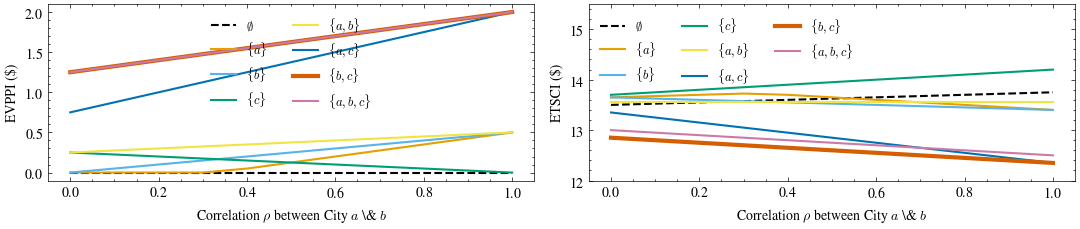

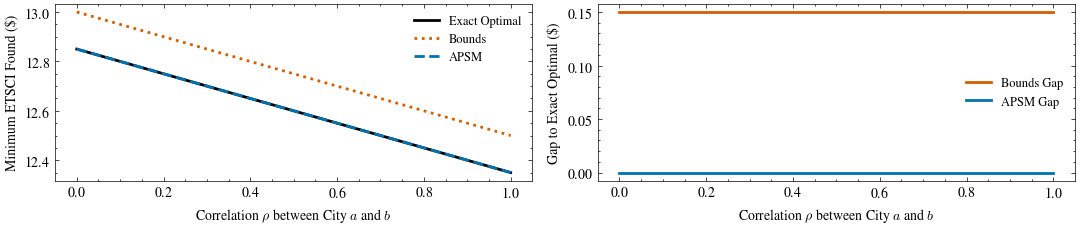

   rho  Exact_Opt  Bounds_Opt  APSM_Opt  ETSCI_{}  ETSCI_{a}  ETSCI_{b}  \
0  0.0      12.85       13.00     12.85    13.500     13.650     13.650   
1  0.1      12.80       12.95     12.80    13.525     13.675     13.625   
2  0.2      12.75       12.90     12.75    13.550     13.700     13.600   
3  0.3      12.70       12.85     12.70    13.575     13.725     13.575   
4  0.4      12.65       12.80     12.65    13.600     13.700     13.550   

   ETSCI_{c}  ETSCI_{a,b}  ETSCI_{a,c}  ETSCI_{b,c}  ETSCI_{a,b,c}  EVPPI_{}  \
0      13.70        13.55        13.35        12.85          13.00       0.0   
1      13.75        13.55        13.25        12.80          12.95       0.0   
2      13.80        13.55        13.15        12.75          12.90       0.0   
3      13.85        13.55        13.05        12.70          12.85       0.0   
4      13.90        13.55        12.95        12.65          12.80       0.0   

   EVPPI_{a}  EVPPI_{b}  EVPPI_{c}  EVPPI_{a,b}  EVPPI_{a,c}  EVPPI_

In [10]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5
cap_dc = 4.0
cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}
G = ['a', 'b', 'c']

def calc_cost(total_demand, num_dcs):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def build_interpolated_scenarios(rho):
    """Interpolates probabilities between Independent (rho=0) and Correlated a,b (rho=1)"""
    scenarios = []
    for a, b, c in itertools.product([1, 3], [1, 4], [1, 5]):
        p_ind = 0.125
        # Perfectly correlated logic: if a=1 -> b=1. If a=3 -> b=4. (c remains independent)
        p_corr = 0.25 if ((a == 1 and b == 1) or (a == 3 and b == 4)) else 0.0

        p_final = (1 - rho) * p_ind + rho * p_corr
        if p_final > 1e-9:
            scenarios.append({'a': a, 'b': b, 'c': c, 'prob': p_final, 'total_demand': a + b + c})
    return pd.DataFrame(scenarios)

def evaluate_ws(phi, df_scen, allowed_dcs=[1, 2, 3]):
    if not phi:
        costs = [(df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() for dcs in allowed_dcs]
        return min(costs)

    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        costs = [(group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() / group_prob for dcs in allowed_dcs]
        ws_phi += group_prob * min(costs)
    return ws_phi

def CGI(phi):
    return sum(cgis[i] for i in phi)


# =============================================================================
# 2. Simulation over Correlation (rho)
# =============================================================================
rhos = np.linspace(0.0, 1.0, 11)
results = []
all_subsets = [list(subset) for L in range(4) for subset in itertools.combinations(G, L)]

for rho in rhos:
    df_scen = build_interpolated_scenarios(rho)

    # --- Exact Evaluation for all subsets ---
    etsci_vals = {}
    evppi_vals = {}
    ws_empty = evaluate_ws([], df_scen)
    ws_G = evaluate_ws(G, df_scen)
    EVPI = ws_empty - ws_G

    for phi in all_subsets:
        # Formatting keys with braces for internal tracking
        phi_key = "{" + ",".join(phi) + "}" if phi else "{}"
        ws_phi = evaluate_ws(phi, df_scen)

        etsci_vals[f'ETSCI_{phi_key}'] = ws_phi + CGI(phi)
        evppi_vals[f'EVPPI_{phi_key}'] = ws_empty - ws_phi

    just_etsci = {k.replace('ETSCI_', ''): v for k, v in etsci_vals.items()}
    exact_min_etsci = min(just_etsci.values())

    # --- Bounds & APSM logic remains the same ---
    EVPPI_i = {i: ws_empty - evaluate_ws([i], df_scen) for i in G}
    phi_B_star = [i for i in G if CGI([i]) - EVPPI_i[i] <= 0]
    ETSCI_bounds = evaluate_ws(phi_B_star, df_scen) + CGI(phi_B_star)

    phi_breve = phi_B_star
    ETSCI_breve = ETSCI_bounds
    if just_etsci["{}"] < ETSCI_breve:
        phi_breve, ETSCI_breve = [], just_etsci["{}"]
    if just_etsci["{a,b,c}"] < ETSCI_breve:
        phi_breve, ETSCI_breve = G, just_etsci["{a,b,c}"]

    T, N = 10, len(G)
    R = 2 * np.sqrt(N)
    L = max(np.abs(np.sum(list(EVPPI_i.values())) - EVPI), 1e-5)
    eta = R / (L * np.sqrt(T))

    def tilde_ETSCI(subset_phi):
        diff_set = [x for x in G if x not in subset_phi]
        return evaluate_ws(diff_set, df_scen) + CGI(diff_set) - just_etsci["{a,b,c}"]

    varphi = np.array([1.0 if g in phi_breve else 0.0 for g in G])
    for t in range(T):
        sort_idx = np.argsort(-varphi)
        phi_N = [G[i] for i in sort_idx]
        kappa = np.zeros(N)
        for l in range(N):
            kappa[sort_idx[l]] = tilde_ETSCI(phi_N[:l+1]) - tilde_ETSCI(phi_N[:l])
        varphi = np.clip(varphi - eta * kappa, 0, 1)

    final_sort_idx = np.argsort(-varphi)
    hat_phi_N = [G[i] for i in final_sort_idx]
    m_val, tilde_phi = tilde_ETSCI([]), []
    for i in range(N):
        if tilde_ETSCI(hat_phi_N[:i+1]) < m_val:
            m_val = tilde_ETSCI(hat_phi_N[:i+1])
            tilde_phi = hat_phi_N[:i+1]

    hat_phi = sorted([x for x in G if x not in tilde_phi])
    ETSCI_apsm = evaluate_ws(hat_phi, df_scen) + CGI(hat_phi)

    row = {'rho': rho, 'Exact_Opt': exact_min_etsci, 'Bounds_Opt': ETSCI_breve, 'APSM_Opt': ETSCI_apsm}
    row.update(etsci_vals)
    row.update(evppi_vals)
    results.append(row)

# Create DataFrame and round to 3 decimal places
df_res = pd.DataFrame(results).round(3)


# =============================================================================
# 3. Visualizations (Okabe-Ito Palette & LaTeX Rendering)
# =============================================================================
import matplotlib.pyplot as plt

# Use the science style
plt.style.use(['science', 'no-latex'])

okabe_ito = {
    "{}":      "#000000",
    "{a}":     "#E69F00",
    "{b}":     "#56B4E9",
    "{c}":     "#009E73",
    "{a,b}":   "#F0E442",
    "{a,c}":   "#0072B2",
    "{b,c}":   "#D55E00",
    "{a,b,c}": "#CC79A7"
}

def format_label(key):
    """Escapes braces for LaTeX rendering in scienceplots"""
    if key == "{}":
        return r"$\emptyset$"
    else:
        # Strip the standard braces and wrap in escaped LaTeX braces
        inner_text = key.replace("{", "").replace("}", "")
        return r"$\{" + inner_text + r"\}$"

# ---------------------------------------------------------
# FIGURE 1: EVPPI and ETSCI
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 2.5))

# Chart 1A: EVPPI
for key, color in okabe_ito.items():
    lw = 3 if key in ["{b,c}"] else 1.5
    ls = '--' if key == "{}" else '-'
    lbl = format_label(key)

    axes1[0].plot(df_res['rho'], df_res[f'EVPPI_{key}'], label=lbl, color=color, linewidth=lw, linestyle=ls)

#axes1[0].set_title('EVPPI vs Correlation', fontsize=12)
axes1[0].set_xlabel(r'Correlation $\rho$ between City $a$ \& $b$', fontsize=10)
axes1[0].set_ylabel(r'EVPPI (\$)', fontsize=10)
axes1[0].legend(fontsize=9, loc='best', ncol=2)
axes1[0].grid(False)

# Chart 1B: ETSCI
for key, color in okabe_ito.items():
    lw = 3 if key in ["{b,c}"] else 1.5
    ls = '--' if key == "{}" else '-'
    lbl = format_label(key)

    axes1[1].plot(df_res['rho'], df_res[f'ETSCI_{key}'], label=lbl, color=color, linewidth=lw, linestyle=ls)

#axes1[1].set_title('ETSCI vs Correlation', fontsize=12)
axes1[1].set_xlabel(r'Correlation $\rho$ between City $a$ \& $b$', fontsize=10)
axes1[1].set_ylim(12, 15.5)
axes1[1].set_ylabel(r'ETSCI (\$)', fontsize=10)
axes1[1].legend(fontsize=9, loc='best', ncol=3)
axes1[1].grid(False)

plt.tight_layout()
plt.savefig('correlationevppietsci.pdf', dpi=300)
plt.show()

# ---------------------------------------------------------
# FIGURE 2: Performance and Gap
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 2.5))

color_exact = "#000000"
color_bounds = "#D55E00"
color_apsm = "#0072B2"

# Chart 2A: Performance
axes2[0].plot(df_res['rho'], df_res['Exact_Opt'], label='Exact Optimal', color=color_exact, linewidth=2)
axes2[0].plot(df_res['rho'], df_res['Bounds_Opt'], label='Bounds', color=color_bounds, linestyle=':', linewidth=2)
axes2[0].plot(df_res['rho'], df_res['APSM_Opt'], label='APSM', color=color_apsm, linestyle='--', linewidth=2)

#axes2[0].set_title('Algorithm Performance vs Correlation', fontsize=12)
axes2[0].set_xlabel(r'Correlation $\rho$ between City $a$ and $b$', fontsize=10)
axes2[0].set_ylabel(r'Minimum ETSCI Found (\$)', fontsize=10)
axes2[0].legend(fontsize=9, loc='best')
axes2[0].grid(False)

# Chart 2B: Optimality Gap
axes2[1].plot(df_res['rho'], (df_res['Bounds_Opt'] - df_res['Exact_Opt']), label='Bounds Gap', color=color_bounds, linewidth=2)
axes2[1].plot(df_res['rho'], (df_res['APSM_Opt'] - df_res['Exact_Opt']), label='APSM Gap', color=color_apsm, linewidth=2)

#axes2[1].set_title('Absolute Optimality Gap vs Correlation', fontsize=12)
axes2[1].set_xlabel(r'Correlation $\rho$ between City $a$ and $b$', fontsize=10)
axes2[1].set_ylabel(r'Gap to Exact Optimal (\$)', fontsize=10)
axes2[1].legend(fontsize=9, loc='best')
axes2[1].grid(False)

plt.tight_layout()
plt.savefig('correlationoptimality.pdf', dpi=300)
plt.show()

# Display Rounded DataFrame head
print(df_res.head())


# EVSI/EVII Example and Inaccuracy Analysis

Running Sensitivity Analysis on Survey Accuracy...


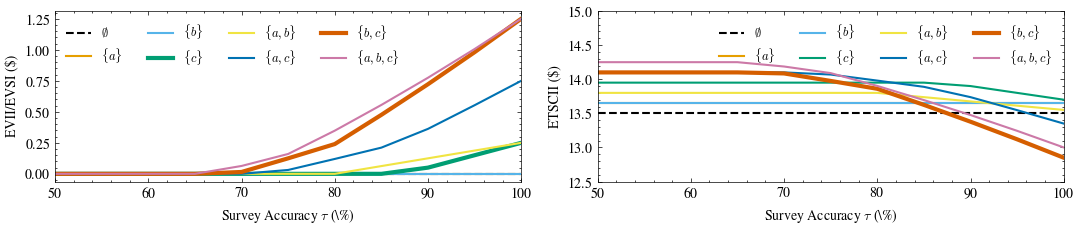


CRITICAL THRESHOLD ANALYSIS:
ETSCII({b,c}) intersects ETSCII(Empty) exactly at survey accuracy tau = 0.8755 (87.55%)
If survey accuracy drops below this threshold, gathering NO information is optimal.



In [11]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5
cap_dc = 4.0
G = ['a', 'b', 'c']

demands = {
    'a': [1, 3],
    'b': [1, 4],
    'c': [1, 5]
}

cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def calc_cost(total_demand, num_dcs):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def CGI(phi):
    return sum(cgis[i] for i in phi)

# Baseline Wait-and-See (No Information)
# Expected costs for 1, 2, or 3 DCs over the independent base distribution
base_scenarios = []
for a, b, c in itertools.product(demands['a'], demands['b'], demands['c']):
    base_scenarios.append({'prob': 0.125, 'total_demand': a + b + c})
df_base = pd.DataFrame(base_scenarios)

ws_empty = min(
    (df_base['prob'] * df_base['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum()
    for dcs in [1, 2, 3]
)

# =============================================================================
# 2. Noisy Signal (EVSI) Evaluator
# =============================================================================
def get_joint_probabilities(phi, accuracy):
    """
    Builds the joint probability distribution of (True State, Noisy Signal).
    Accuracy p: P(Signal = x | True = x) = p
    """
    joint_scenarios = []

    for true_a, true_b, true_c in itertools.product(demands['a'], demands['b'], demands['c']):
        prob_true = 0.125

        # Determine signal options and probabilities for each city
        sig_options = []
        for city, true_val in zip(['a', 'b', 'c'], [true_a, true_b, true_c]):
            if city in phi:
                # The other possible state for this city
                other_val = [v for v in demands[city] if v != true_val][0]
                sig_options.append([(true_val, accuracy), (other_val, 1 - accuracy)])
            else:
                # If not surveyed, there is no signal (None with 100% prob)
                sig_options.append([(None, 1.0)])

        # Create all possible combinations of signals for this true state
        for (sig_a, p_a), (sig_b, p_b), (sig_c, p_c) in itertools.product(*sig_options):
            joint_prob = prob_true * p_a * p_b * p_c
            joint_scenarios.append({
                'sig_a': sig_a, 'sig_b': sig_b, 'sig_c': sig_c,
                'prob': joint_prob,
                'total_demand': true_a + true_b + true_c
            })

    return pd.DataFrame(joint_scenarios)

def evaluate_ws_imperfect(phi, accuracy):
    """Evaluates Wait-and-See under imperfect information (EVSI)."""
    if not phi:
        return ws_empty

    df_joint = get_joint_probabilities(phi, accuracy)
    ws_imp = 0.0

    # The decision-maker only observes the signals for the surveyed cities
    sig_cols = ['sig_' + c for c in phi]
    grouped = df_joint.groupby(sig_cols)

    for _, group in grouped:
        group_prob = group['prob'].sum()
        if group_prob == 0:
            continue

        # Find the optimal DC decision given this specific combination of noisy signals
        costs = []
        for dcs in [1, 2, 3]:
            c = (group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() / group_prob
            costs.append(c)

        ws_imp += group_prob * min(costs)

    return ws_imp

# =============================================================================
# 3. Simulation over Signal Accuracy (50% to 100%)
# =============================================================================
accuracies = np.linspace(0.5, 1.0, 11)  # 50% to 100% in 5% increments
all_subsets = [list(subset) for L in range(4) for subset in itertools.combinations(G, L)]

evsi_results = []
etsci_results = []

print("Running Sensitivity Analysis on Survey Accuracy...")
for acc in accuracies:
    row_evsi = {'Accuracy': acc}
    row_etsci = {'Accuracy': acc}

    for phi in all_subsets:
        phi_key = "{" + ",".join(phi) + "}" if phi else "{}"

        ws_imp = evaluate_ws_imperfect(phi, acc)
        evsi = ws_empty - ws_imp
        etsci = ws_imp + CGI(phi)

        row_evsi[phi_key] = evsi
        row_etsci[phi_key] = etsci

    evsi_results.append(row_evsi)
    etsci_results.append(row_etsci)

df_evsi = pd.DataFrame(evsi_results)
df_etsci = pd.DataFrame(etsci_results)

# =============================================================================
# 4. Visualizations (Okabe-Ito Palette, SciencePlots, & LaTeX Rendering)
# =============================================================================
import matplotlib.pyplot as plt

# Use the science style
plt.style.use(['science', 'no-latex'])

okabe_ito = {
    "{}":      "#000000", "{a}":     "#E69F00", "{b}":     "#56B4E9",
    "{c}":     "#009E73", "{a,b}":   "#F0E442", "{a,c}":   "#0072B2",
    "{b,c}":   "#D55E00", "{a,b,c}": "#CC79A7"
}

def format_label(key):
    """Escapes braces for LaTeX rendering in scienceplots"""
    if key == "{}":
        return r"$\emptyset$"
    else:
        # Strip the standard braces and wrap in escaped LaTeX braces
        inner_text = key.replace("{", "").replace("}", "")
        return r"$\{" + inner_text + r"\}$"

fig, axes = plt.subplots(1, 2, figsize=(11, 2.5))

# Chart 1: EVSI vs Accuracy
for key, color in okabe_ito.items():
    # Re-adding the line width logic so {b,c} and {c} stand out
    lw = 3 if key in ["{b,c}", "{c}"] else 1.5
    ls = '--' if key == "{}" else '-'
    lbl = format_label(key)
    axes[0].plot(df_evsi['Accuracy'] * 100, df_evsi[key], label=lbl, color=color, linewidth=lw, linestyle=ls)

#axes[0].set_title('a) EVII/EVSI vs. Survey Accuracy', fontsize=12)
axes[0].set_xlabel(r'Survey Accuracy $\tau$ (\%)', fontsize=10) # Used raw string r'...'
axes[0].set_ylabel(r'EVII/EVSI (\$)', fontsize=10)
axes[0].set_xlim(50, 100)
axes[0].legend(fontsize=9, loc='upper left', ncol=4)
axes[0].grid(False) # Ensure gridlines are removed

# Chart 2: ETSCI vs Accuracy
for key, color in okabe_ito.items():
    lw = 3 if key in ["{b,c}"] else 1.5
    ls = '--' if key == "{}" else '-'
    lbl = format_label(key)
    axes[1].plot(df_etsci['Accuracy'] * 100, df_etsci[key], label=lbl, color=color, linewidth=lw, linestyle=ls)

#axes[1].set_title('ETSCI vs. Survey Accuracy', fontsize=12)
axes[1].set_xlabel(r'Survey Accuracy $\tau$ (\%)', fontsize=10)
axes[1].set_ylabel(r'ETSCII (\$)', fontsize=10)
axes[1].set_xlim(50, 100)
axes[1].set_ylim(12.5, 15)
axes[1].legend(fontsize=9, loc='upper right', ncol=4)
axes[1].grid(False) # Ensure gridlines are removed

plt.tight_layout()
plt.savefig('informationaccuracyanalysis.pdf', dpi=300)
plt.show()

# =============================================================================
# 5. Calculate Exact Crossover Threshold for {b,c} vs Empty Set
# =============================================================================
from scipy.optimize import brentq

def etscii_diff(tau):
    """
    Returns the difference between ETSCII({b,c}) and ETSCII(Empty).
    We want to find the root where this difference is exactly 0.
    """
    etsci_bc = evaluate_ws_imperfect(['b', 'c'], tau) + CGI(['b', 'c'])
    return etsci_bc - ws_empty

# Find the exact root between tau=0.5 and tau=1.0
try:
    crossover_tau = brentq(etscii_diff, 0.5, 1.0)
    print("\n" + "="*60)
    print(f"CRITICAL THRESHOLD ANALYSIS:")
    print(f"ETSCII({{b,c}}) intersects ETSCII(Empty) exactly at survey accuracy tau = {crossover_tau:.4f} ({crossover_tau*100:.2f}%)")
    print("If survey accuracy drops below this threshold, gathering NO information is optimal.")
    print("="*60 + "\n")
except ValueError:
    print("No crossover point found between 50% and 100% accuracy.")

# Information Cost Inaccuracy Analysis

Running Sensitivity Analysis on Information Cost and Accuracy...


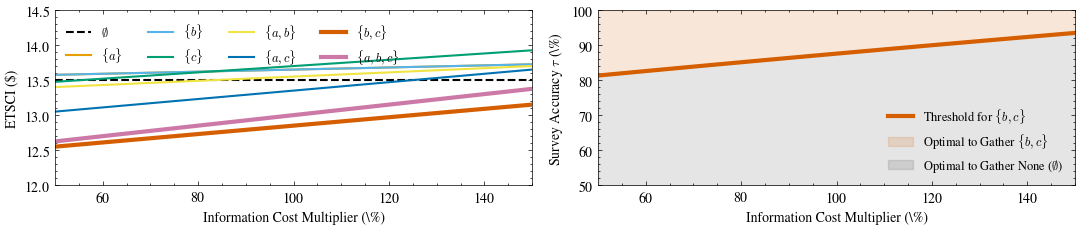

In [12]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Use the science style
plt.style.use(['science', 'no-latex'])

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5
cap_dc = 4.0
G = ['a', 'b', 'c']

demands = {'a': [1, 3], 'b': [1, 4], 'c': [1, 5]}
base_cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def calc_cost(total_demand, num_dcs):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

base_scenarios = []
for a, b, c in itertools.product(demands['a'], demands['b'], demands['c']):
    base_scenarios.append({'prob': 0.125, 'total_demand': a + b + c})
df_base = pd.DataFrame(base_scenarios)

ws_empty = min(
    (df_base['prob'] * df_base['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum()
    for dcs in [1, 2, 3]
)

def get_joint_probabilities(phi, accuracy):
    joint_scenarios = []
    for true_a, true_b, true_c in itertools.product(demands['a'], demands['b'], demands['c']):
        prob_true = 0.125
        sig_options = []
        for city, true_val in zip(['a', 'b', 'c'], [true_a, true_b, true_c]):
            if city in phi:
                other_val = [v for v in demands[city] if v != true_val][0]
                sig_options.append([(true_val, accuracy), (other_val, 1 - accuracy)])
            else:
                sig_options.append([(None, 1.0)])
        for (sig_a, p_a), (sig_b, p_b), (sig_c, p_c) in itertools.product(*sig_options):
            joint_prob = prob_true * p_a * p_b * p_c
            joint_scenarios.append({
                'sig_a': sig_a, 'sig_b': sig_b, 'sig_c': sig_c,
                'prob': joint_prob,
                'total_demand': true_a + true_b + true_c
            })
    return pd.DataFrame(joint_scenarios)

def evaluate_ws_imperfect(phi, accuracy):
    if not phi: return ws_empty
    df_joint = get_joint_probabilities(phi, accuracy)
    ws_imp = 0.0
    sig_cols = ['sig_' + c for c in phi]
    grouped = df_joint.groupby(sig_cols)
    for _, group in grouped:
        group_prob = group['prob'].sum()
        if group_prob == 0: continue
        costs = []
        for dcs in [1, 2, 3]:
            c = (group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() / group_prob
            costs.append(c)
        ws_imp += group_prob * min(costs)
    return ws_imp

# =============================================================================
# 2. Simulation: Varying Information Prices (+/- 50%)
# =============================================================================
all_subsets = [list(subset) for L in range(4) for subset in itertools.combinations(G, L)]
cost_multipliers = np.linspace(0.5, 1.5, 21) # From 50% (-50%) to 150% (+50%)

etsci_cost_results = []
threshold_results = []

print("Running Sensitivity Analysis on Information Cost and Accuracy...")

for cm in cost_multipliers:
    # --- Part A: ETSCI vs Cost Multiplier (Perfect Accuracy) ---
    row_etsci = {'Cost_Mult': cm}
    for phi in all_subsets:
        phi_key = "{" + ",".join(phi) + "}" if phi else "{}"
        ws_perf = evaluate_ws_imperfect(phi, 1.0)
        cost_of_info = cm * sum(base_cgis[i] for i in phi)
        row_etsci[phi_key] = ws_perf + cost_of_info
    etsci_cost_results.append(row_etsci)

    # --- Part B: Accuracy Threshold vs Cost Multiplier for {b,c} ---
    def diff_func(tau):
        ws_imp = evaluate_ws_imperfect(['b', 'c'], tau)
        cost_of_info = cm * sum(base_cgis[i] for i in ['b', 'c'])
        return (ws_imp + cost_of_info) - ws_empty

    try:
        # If difference > 0 even at perfect accuracy, survey is too expensive
        if diff_func(1.0) > 0:
            threshold = np.nan
        # Find exact crossover where ETSCI({b,c}) == WS_Empty
        else:
            threshold = brentq(diff_func, 0.5, 1.0)
    except ValueError:
        threshold = np.nan

    threshold_results.append({'Cost_Mult': cm, 'Threshold': threshold})

df_etsci_c = pd.DataFrame(etsci_cost_results)
df_thresh = pd.DataFrame(threshold_results)

# =============================================================================
# 3. Visualizations
# =============================================================================
okabe_ito = {
    "{}":      "#000000", "{a}":     "#E69F00", "{b}":     "#56B4E9",
    "{c}":     "#009E73", "{a,b}":   "#F0E442", "{a,c}":   "#0072B2",
    "{b,c}":   "#D55E00", "{a,b,c}": "#CC79A7"
}

def format_label(key):
    if key == "{}": return r"$\emptyset$"
    inner = key.replace("{", "").replace("}", "")
    return r"$\{" + inner + r"\}$"

fig, axes = plt.subplots(1, 2, figsize=(11, 2.5))

# Chart 1: ETSCI vs Cost Multiplier
for key, color in okabe_ito.items():
    lw = 3 if key in ["{b,c}", "{a,b,c}"] else 1.5
    ls = '--' if key == "{}" else '-'
    lbl = format_label(key)
    axes[0].plot(df_etsci_c['Cost_Mult'] * 100, df_etsci_c[key], label=lbl, color=color, linewidth=lw, linestyle=ls)

axes[0].set_xlabel(r'Information Cost Multiplier (\%)', fontsize=10)
axes[0].set_ylabel(r'ETSCI (\$)', fontsize=10)
axes[0].set_xlim(50, 150)
axes[0].set_ylim(12, 14.5)
axes[0].legend(fontsize=9, loc='upper left', ncol=4)
axes[0].grid(False)

# Chart 2: Accuracy Threshold vs Cost for {b,c}
x_vals = df_thresh['Cost_Mult'] * 100
y_thresh = df_thresh['Threshold'] * 100

# 1. Plot the threshold line
axes[1].plot(x_vals, y_thresh,
             color=okabe_ito["{b,c}"], linewidth=3, label=r'Threshold for $\{b,c\}$')

# 2. Fill ABOVE the threshold (Optimal to Gather {b,c})
# Note: fill_between naturally ignores NaNs, so it perfectly stops when the line breaks
axes[1].fill_between(x_vals, y_thresh, 100,
                     color=okabe_ito["{b,c}"], alpha=0.15, label=r'Optimal to Gather $\{b,c\}$')

# 3. Fill BELOW the threshold (Optimal to Gather None)
# Note: fillna(100) ensures the "Gather None" shading continues filling the right side
# of the chart even after the cost becomes too high to justify surveying.
axes[1].fill_between(x_vals, 50, y_thresh.fillna(100),
                     color=okabe_ito["{}"], alpha=0.1, label=r'Optimal to Gather None ($\emptyset$)')

axes[1].set_xlabel(r'Information Cost Multiplier (\%)', fontsize=10)
axes[1].set_ylabel(r'Survey Accuracy $\tau$ (\%)', fontsize=10)
axes[1].set_xlim(50, 150)
axes[1].set_ylim(50, 100)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('informationcostanalysis.pdf', dpi=300)
plt.show()

# Sensitivity Analysis of (α, β)-weakly DR Modularity to Solution Quality

In [19]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import timeit
from tqdm import tqdm  

# Use the science style for publication-ready plots
plt.style.use(['science', 'no-latex'])

# =============================================================================
# 1. SCND Evaluator Setup
# =============================================================================
COST_DC = 4.0
COST_OP = 0.5
COST_PEN = 2.5
cap_dc = 4.0
G = ['a', 'b', 'c']
cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def calc_cost(total_demand, num_dcs):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (COST_DC * num_dcs) + (COST_OP * fulfilled) + (COST_PEN * unmet)

def CGI(phi):
    return sum(cgis[i] for i in phi)

def evaluate_ws_dynamic(phi, df_scen):
    if not phi:
        costs = [(df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() for dcs in [1, 2, 3]]
        return min(costs)
    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        if group_prob == 0: continue
        costs = [(group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs))).sum() / group_prob for dcs in [1, 2, 3]]
        ws_phi += group_prob * min(costs)
    return ws_phi

# =============================================================================
# 2. Simulation Engine (Generating alpha, beta, and ratios)
# =============================================================================
N_SIM = 100000  # Set to 50000 for the full paper run
np.random.seed(0)

# ---> DEFINE EPSILON HERE <---
EPSILON = 0.15

results = []
print(f"Running {N_SIM} Monte Carlo simulations with Epsilon = {EPSILON}...")
start_time = timeit.default_timer()

# ---> TQDM WRAPPER ADDED HERE <---
for sim in tqdm(range(N_SIM), desc="Simulation Progress", unit="sim"):

    d1 = np.random.uniform(0, 5, 3)
    d2 = np.random.uniform(0, 8, 3)
    demands = {'a': [d1[0], d2[0]], 'b': [d1[1], d2[1]], 'c': [d1[2], d2[2]]}

    scenarios = []
    for a, b, c in itertools.product(demands['a'], demands['b'], demands['c']):
        scenarios.append({'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a + b + c})
    df_scen = pd.DataFrame(scenarios)

    ws_vals = {}
    etsci_vals = {}
    all_subsets = [list(s) for L in range(4) for s in itertools.combinations(G, L)]

    for phi in all_subsets:
        phi_key = frozenset(phi)
        ws = evaluate_ws_dynamic(phi, df_scen)
        ws_vals[phi_key] = ws
        etsci_vals[phi_key] = ws + CGI(phi)

    ws_empty = ws_vals[frozenset()]
    etsci_empty = etsci_vals[frozenset()]
    etsci_G = etsci_vals[frozenset(G)]

    exact_phi = min(etsci_vals, key=etsci_vals.get)
    exact_etsci = etsci_vals[exact_phi]

    # ---------------------------------------------------------
    # Bounds Solution (Breve phi)
    # ---------------------------------------------------------
    phi_B_star = [i for i in G if CGI([i]) - (ws_empty - ws_vals[frozenset([i])]) <= 0]
    etsci_B_star = etsci_vals[frozenset(phi_B_star)]

    phi_breve, etsci_breve = phi_B_star, etsci_B_star
    if etsci_empty < etsci_breve:
        phi_breve, etsci_breve = [], etsci_empty
    if etsci_G < etsci_breve:
        phi_breve, etsci_breve = G, etsci_G

    bounds_correct = int(frozenset(phi_breve) == exact_phi)

    denom = exact_etsci - etsci_empty
    if denom == 0:
        bounds_ratio = 1.0 if etsci_breve == etsci_empty else 0.0
    else:
        bounds_ratio = (etsci_breve - etsci_empty) / denom

    # ---------------------------------------------------------
    # APSM Algorithm
    # ---------------------------------------------------------
    EVPPI_i = {i: ws_empty - ws_vals[frozenset([i])] for i in G}
    EVPI = ws_empty - ws_vals[frozenset(G)]

    T, N = 10, len(G)
    R = 2 * np.sqrt(N)
    L = max(np.abs(np.sum(list(EVPPI_i.values())) - EVPI), 1e-5)
    eta = R / (L * np.sqrt(T))

    def tilde_ETSCI(subset_phi):
        diff_set = frozenset([x for x in G if x not in subset_phi])
        return etsci_vals[diff_set] - etsci_G

    varphi = np.array([1.0 if g in phi_breve else 0.0 for g in G])
    for t in range(T):
        sort_idx = np.argsort(-varphi)
        phi_N = [G[i] for i in sort_idx]
        kappa = np.zeros(N)
        for l in range(N):
            kappa[sort_idx[l]] = tilde_ETSCI(phi_N[:l+1]) - tilde_ETSCI(phi_N[:l])
        varphi = np.clip(varphi - eta * kappa, 0, 1)

    final_sort_idx = np.argsort(-varphi)
    hat_phi_N = [G[i] for i in final_sort_idx]
    m_val, tilde_phi = tilde_ETSCI([]), []
    for i in range(N):
        val = tilde_ETSCI(hat_phi_N[:i+1])
        if val < m_val:
            m_val, tilde_phi = val, hat_phi_N[:i+1]

    apsm_phi = frozenset([x for x in G if x not in tilde_phi])
    apsm_etsci = etsci_vals[apsm_phi]
    apsm_correct = int(apsm_phi == exact_phi)

    if denom == 0:
        apsm_ratio = 1.0 if apsm_etsci == etsci_empty else 0.0
    else:
        apsm_ratio = (apsm_etsci - etsci_empty) / denom

    # ---------------------------------------------------------
    # Calculate True & Estimated Alpha, Beta (WITH EPSILON)
    # ---------------------------------------------------------
    # Apply transformation: WS_hat(phi) = WS(phi) - eps * |phi|
    ws_hat_vals = {phi: ws_vals[phi] - (EPSILON * len(phi)) for phi in ws_vals}

    # Calculate difference using the transformed WS_hat
    def diff_ws_hat(A, i):
        return abs(ws_hat_vals[frozenset(A).union({i})] - ws_hat_vals[frozenset(A)])

    alphas, betas = [], []
    for a in all_subsets:
        for b in all_subsets:
            if set(a).issubset(set(b)):
                for i in G:
                    if i not in b:
                        num = diff_ws_hat(a, i)
                        den = diff_ws_hat(b, i)
                        if den > 1e-7: alphas.append(num / den)
                        if num > 1e-7: betas.append(den / num)

    alpha_true = max(alphas) if alphas else 1.0
    beta_true = max(betas) if betas else 1.0

    hat_alphas, hat_betas = [], []
    for i in G:
        for j in G:
            if i != j:
                num = diff_ws_hat([], i)
                den = diff_ws_hat([j], i)
                if den > 1e-7: hat_alphas.append(num / den)
                if num > 1e-7: hat_betas.append(den / num)

    alpha_hat = max(1.0, max(hat_alphas) if hat_alphas else 1.0)
    beta_hat = max(1.0, max(hat_betas) if hat_betas else 1.0)

    results.append({
        'Alpha': min(alpha_true, 5.0),
        'Beta': min(beta_true, 5.0),
        'Alpha_Hat': max(min(alpha_hat, 5.0), 1.0),
        'Beta_Hat': max(min(beta_hat, 5.0), 1.0),
        'Correct_Bounds': bounds_correct,
        'Ratio_Bounds': bounds_ratio * 100,
        'Correct_APSM': apsm_correct,
        'Ratio_APSM': apsm_ratio * 100
    })

print(f"\nSimulation completed in {timeit.default_timer() - start_time:.2f} seconds.")
df_sim = pd.DataFrame(results)

Running 100000 Monte Carlo simulations with Epsilon = 0.15...


Simulation Progress: 100%|██████████| 100000/100000 [31:27<00:00, 52.99sim/s] 



Simulation completed in 1887.19 seconds.


In [20]:
df_sim.to_csv('simulation_results_raw.csv', index=False)
# Create the initial DataFrame
df_sim = pd.DataFrame(results)

# 1. Enforce the theoretical lower bound of 1.0 for the estimators
df_sim['Alpha_Hat'] = df_sim['Alpha_Hat'].clip(lower=1.0)
df_sim['Beta_Hat'] = df_sim['Beta_Hat'].clip(lower=1.0)

# 2. Remove rows where the savings ratio is exactly 0
# (i.e., no savings were captured or the optimal action was to do nothing)
df_sim = df_sim[(df_sim['Ratio_Bounds'] != 0) & (df_sim['Ratio_APSM'] != 0)]
df_sim = df_sim[(df_sim['Alpha'] != 5) & (df_sim['Beta'] != 5)]

# (Optional) Reset the index after dropping rows so your dataframe is clean
df_sim = df_sim.reset_index(drop=True)

print(f"Data cleaned. Remaining valid simulation scenarios: {len(df_sim)}")

Data cleaned. Remaining valid simulation scenarios: 81725


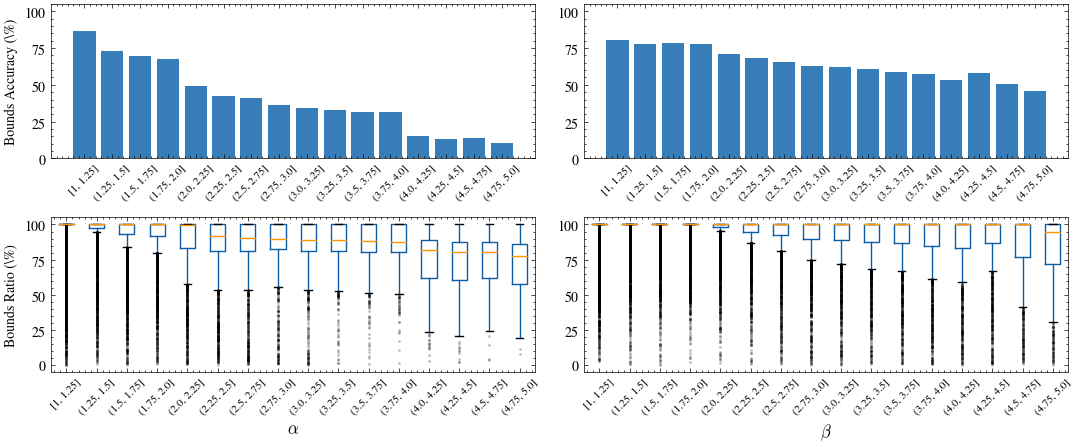

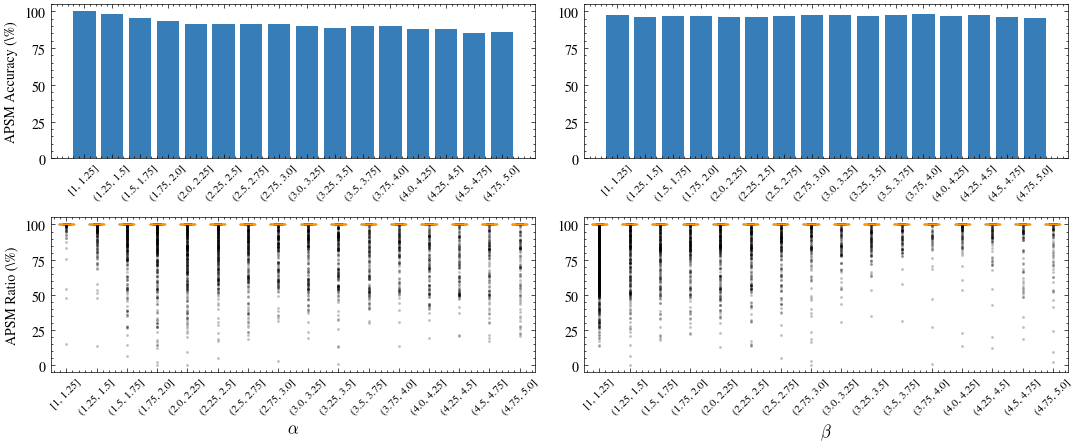

In [22]:
# =============================================================================
# 3. Visualization Function
# =============================================================================
def plot_sensitivity(df, method_name, ratio_col, correct_col, filename):
    bins = np.arange(1, 5.25, 0.25)
    df = df.copy()

    df['Alpha_bin'] = pd.cut(df['Alpha'], bins=bins, include_lowest=True, right=True)
    df['Beta_bin'] = pd.cut(df['Beta'], bins=bins, include_lowest=True, right=True)

    df['Alpha_bin'] = df['Alpha_bin'].astype(str).replace("(0.999, 1.25]", "[1, 1.25]")
    df['Beta_bin'] = df['Beta_bin'].astype(str).replace("(0.999, 1.25]", "[1, 1.25]")

    df['Alpha_bin'] = pd.Categorical(df['Alpha_bin'], ordered=True,
                      categories=sorted(df['Alpha_bin'].unique(), key=lambda x: float(x.split(',')[0][1:])))
    df['Beta_bin'] = pd.Categorical(df['Beta_bin'], ordered=True,
                     categories=sorted(df['Beta_bin'].unique(), key=lambda x: float(x.split(',')[0][1:])))

    fig, axes = plt.subplots(2, 2, figsize=(11, 5.25))

    # Accuracy Histograms
    alpha_acc = df.groupby('Alpha_bin', observed=False)[correct_col].mean() * 100
    axes[0, 0].bar(alpha_acc.index.astype(str), alpha_acc, width=0.8, color='#377eb8')
    axes[0, 0].set_ylabel(rf"{method_name} Accuracy (\%)", fontsize=10)
    axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8)
    axes[0, 0].set_ylim(0, 105)

    beta_acc = df.groupby('Beta_bin', observed=False)[correct_col].mean() * 100
    axes[0, 1].bar(beta_acc.index.astype(str), beta_acc, width=0.8, color='#377eb8')
    axes[0, 1].tick_params(axis='x', rotation=45, labelsize=8)
    axes[0, 1].set_ylim(0, 105)

    # Define outlier properties (very small markers, slightly transparent)
    flier_props = dict(marker='o', markersize=1, alpha=0.25)

    # Ratio Boxplots
    df.boxplot(column=ratio_col, by='Alpha_bin', ax=axes[1, 0], grid=False, flierprops=flier_props)
    axes[1, 0].set_xlabel(r"$\alpha$", fontsize=12)
    axes[1, 0].set_ylabel(rf"{method_name} Ratio (\%)", fontsize=10)
    axes[1, 0].tick_params(axis='x', rotation=45, labelsize=8)

    df.boxplot(column=ratio_col, by='Beta_bin', ax=axes[1, 1], grid=False, flierprops=flier_props)
    axes[1, 1].set_xlabel(r'$\beta$', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=45, labelsize=8)

    for ax in [axes[1, 0], axes[1, 1]]:
        ax.get_figure().suptitle('')
        ax.set_title("")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename, dpi=300) # Uncomment to save
    plt.show()

# Plot Bounds Analysis
plot_sensitivity(df_sim, "Bounds", "Ratio_Bounds", "Correct_Bounds", "bounds_analysis.pdf")

# Plot APSM Analysis
plot_sensitivity(df_sim, "APSM", "Ratio_APSM", "Correct_APSM", "apsm_analysis.pdf")

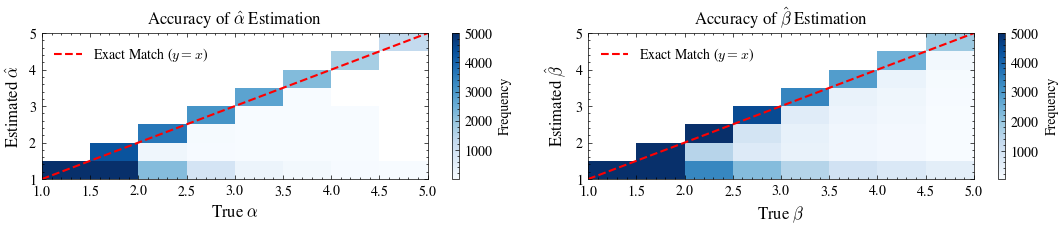

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Use the science style for publication-ready plots
plt.style.use(['science', 'no-latex'])

# Assuming df_sim is already loaded from the previous Monte Carlo simulation
# If running isolated, load your data: df_sim = pd.read_csv('simulation_results.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 2.5))

# Common binning and colormap
bins = 8
cmap = 'Blues'

# ---------------------------------------------------------
# Chart 1: True Alpha vs Estimated Alpha
# ---------------------------------------------------------
# Create the 2D Histogram (Added vmax=20000)
h1 = axes[0].hist2d(df_sim['Alpha'], df_sim['Alpha_Hat'],
                    bins=[bins, bins], range=[[1, 5], [1, 5]],
                    cmap=cmap, cmin=1, vmax=5000) # cmin=1 makes zero-count bins white

# Add the y=x diagonal line for reference
axes[0].plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=1.5, label=r'Exact Match ($y=x$)')

axes[0].set_xlabel(r'True $\alpha$', fontsize=12)
axes[0].set_ylabel(r'Estimated $\hat{\alpha}$', fontsize=12)
axes[0].set_title(r'Accuracy of $\hat{\alpha}$ Estimation', fontsize=12)
axes[0].set_xlim(1, 5)
axes[0].set_ylim(1, 5)
axes[0].legend(loc='upper left', fontsize=10)
fig.colorbar(h1[3], ax=axes[0], label='Frequency')

# ---------------------------------------------------------
# Chart 2: True Beta vs Estimated Beta
# ---------------------------------------------------------
# Create the 2D Histogram (Added vmax=20000)
h2 = axes[1].hist2d(df_sim['Beta'], df_sim['Beta_Hat'],
                    bins=[bins, bins], range=[[1, 5], [1, 5]],
                    cmap=cmap, cmin=1, vmax=5000)

# Add the y=x diagonal line for reference
axes[1].plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=1.5, label=r'Exact Match ($y=x$)')

axes[1].set_xlabel(r'True $\beta$', fontsize=12)
axes[1].set_ylabel(r'Estimated $\hat{\beta}$', fontsize=12)
axes[1].set_title(r'Accuracy of $\hat{\beta}$ Estimation', fontsize=12)
axes[1].set_xlim(1, 5)
axes[1].set_ylim(1, 5)
axes[1].legend(loc='upper left', fontsize=10)
fig.colorbar(h2[3], ax=axes[1], label='Frequency')

plt.tight_layout()
# plt.savefig('alphabetaaccuracy.pdf', dpi=300)
plt.show()

In [18]:
df_sim.head(30)

,Alpha,Beta,Alpha_Hat,Beta_Hat,Correct_Bounds,Ratio_Bounds,Correct_APSM,Ratio_APSM
0,1.292709,3.591709,1.000000,3.591709,0,69.975927,1,100.0
1,1.197157,2.556593,1.000000,2.350498,0,97.816781,1,100.0
2,1.188343,2.442746,1.000000,2.442746,1,100.000000,1,100.0
3,1.000000,1.000000,1.000000,1.000000,1,100.000000,1,100.0
4,1.564732,1.722725,1.000000,1.722725,1,100.000000,1,100.0
5,1.163410,2.862074,1.000000,2.862074,0,98.518256,1,100.0
6,1.000000,3.490422,1.000000,2.129685,1,100.000000,1,100.0
7,3.300506,1.335856,3.300506,1.000000,0,87.789280,1,100.0
8,1.000000,1.000000,1.000000,1.000000,1,100.000000,1,100.0
9,1.000000,2.519401,1.000000,2.010515,0,99.909010,1,100.0


# Epsilon Analysis

Running Part 1: Epsilon Sensitivity...


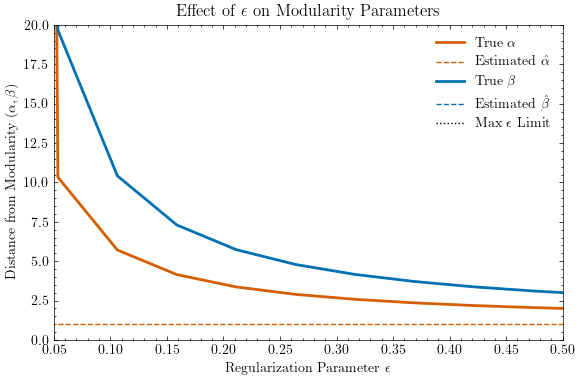

In [ ]:
# import itertools
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import scipy.stats as stats

# plt.style.use(['science', 'no-latex'])

# # =============================================================================
# # Base Setup
# # =============================================================================
# G = ['a', 'b', 'c']
# cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}
# MAX_EPSILON = 1

# def calc_cost(total_demand, num_dcs, cost_dc, cost_op, cost_pen, cap_dc):
#     capacity = cap_dc * num_dcs
#     fulfilled = min(total_demand, capacity)
#     unmet = max(0, total_demand - capacity)
#     return (cost_dc * num_dcs) + (cost_op * fulfilled) + (cost_pen * unmet)

# def evaluate_ws_dynamic(phi, df_scen, cost_dc=4.0, cost_op=0.5, cost_pen=2.5, cap_dc=4.0):
#     if not phi:
#         costs = [(df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() for dcs in [1, 2, 3]]
#         return min(costs)
#     ws_phi = 0.0
#     grouped = df_scen.groupby(list(phi))
#     for _, group in grouped:
#         group_prob = group['prob'].sum()
#         if group_prob == 0: continue
#         costs = [(group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() / group_prob for dcs in [1, 2, 3]]
#         ws_phi += group_prob * min(costs)
#     return ws_phi

# # =============================================================================
# # PART 1: Epsilon Regularization Analysis
# # =============================================================================
# print("Running Part 1: Epsilon Sensitivity...")

# # Base scenario
# scenarios = []
# for a, b, c in itertools.product([1, 3], [1, 4], [1, 5]):
#     scenarios.append({'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a+b+c})
# df_base = pd.DataFrame(scenarios)

# ws_base_vals = {}
# all_subsets = [list(s) for L in range(4) for s in itertools.combinations(G, L)]
# for phi in all_subsets:
#     ws_base_vals[frozenset(phi)] = evaluate_ws_dynamic(phi, df_base)

# epsilons = np.linspace(0.001, MAX_EPSILON, 20)
# eps_results = []

# for eps in epsilons:
#     # Apply transformation: WS_hat(phi) = WS(phi) - eps * |phi|
#     ws_hat = {phi: ws_base_vals[phi] - (eps * len(phi)) for phi in ws_base_vals}

#     def diff_ws_hat(A, i):
#         return abs(ws_hat[frozenset(A).union({i})] - ws_hat[frozenset(A)])

#     # Calculate Alpha and Beta
#     alphas, betas = [], []
#     for a in all_subsets:
#         for b in all_subsets:
#             if set(a).issubset(set(b)):
#                 for i in G:
#                     if i not in b:
#                         num = diff_ws_hat(a, i)
#                         den = diff_ws_hat(b, i)
#                         if den > 1e-7: alphas.append(num / den)
#                         if num > 1e-7: betas.append(den / num)

#     # Calculate Hat Alpha and Hat Beta
#     hat_alphas, hat_betas = [], []
#     for i in G:
#         for j in G:
#             if i != j:
#                 num = diff_ws_hat([], i)
#                 den = diff_ws_hat([j], i)
#                 if den > 1e-7: hat_alphas.append(num / den)
#                 if num > 1e-7: hat_betas.append(den / num)

#     eps_results.append({
#         'Epsilon': eps,
#         'Alpha': max(alphas) if alphas else 1.0,
#         'Beta': max(betas) if betas else 1.0,
#         'Alpha_Hat': max(1.0, max(hat_alphas) if hat_alphas else 1.0),
#         'Beta_Hat': max(1.0, max(hat_betas) if hat_betas else 1.0)
#     })

# df_eps = pd.DataFrame(eps_results)

# # Plot Epsilon Calibration Figure
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(df_eps['Epsilon'], df_eps['Alpha'], label=r'True $\alpha$', color='#D55E00', linewidth=2)
# ax.plot(df_eps['Epsilon'], df_eps['Alpha_Hat'], label=r'Estimated $\hat{\alpha}$', color='#D55E00', linestyle='--')
# ax.plot(df_eps['Epsilon'], df_eps['Beta'], label=r'True $\beta$', color='#0072B2', linewidth=2)
# ax.plot(df_eps['Epsilon'], df_eps['Beta_Hat'], label=r'Estimated $\hat{\beta}$', color='#0072B2', linestyle='--')

# ax.axvline(MAX_EPSILON, color='black', linestyle=':', label=r'Max $\epsilon$ Limit')
# ax.set_xlabel(r'Regularization Parameter $\epsilon$')
# ax.set_ylabel(r'Distance from Modularity ($\alpha, \beta$)')
# ax.set_ylim(0,20)
# ax.set_xlim(0.05,0.50)
# ax.set_title(r'Effect of $\epsilon$ on Modularity Parameters')
# ax.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
# df_eps

In [ ]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
import warnings
from tqdm import tqdm  # <--- Imported tqdm here

# Suppress statsmodels warnings for clean output
warnings.filterwarnings("ignore")

# =============================================================================
# 1. Base Setup & Evaluation Functions
# =============================================================================
G = ['a', 'b', 'c']
all_subsets = [list(s) for L in range(4) for s in itertools.combinations(G, L)]
base_cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def CGI(phi):
    return sum(base_cgis[i] for i in phi)

def calc_cost(total_demand, num_dcs, cost_dc, cost_op, cost_pen, cap_dc):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (cost_dc * num_dcs) + (cost_op * fulfilled) + (cost_pen * unmet)

def evaluate_ws_dynamic(phi, df_scen, cost_dc, cost_op, cost_pen, cap_dc):
    if not phi:
        costs = [(df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() for dcs in [1, 2, 3]]
        return min(costs)
    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        if group_prob == 0: continue
        costs = [(group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() / group_prob for dcs in [1, 2, 3]]
        ws_phi += group_prob * min(costs)
    return ws_phi

# =============================================================================
# 2. Heavy Simulation Engine
# =============================================================================
print("Initializing Monte Carlo Simulation...")
N_SIM = 50000
np.random.seed(42)
results = []

# ---> TQDM WRAPPER ADDED HERE <---
for sim in tqdm(range(N_SIM), desc="Evaluating True Alpha/Beta & Algorithms", unit="sim"):
    # 1. Randomize Primitives
    c_dc = np.random.uniform(2.0, 8.0)
    c_pen = np.random.uniform(1.0, 5.0)
    cap = np.random.uniform(2.0, 6.0)
    eps = np.random.uniform(0.05, 0.20)

    # 2. Randomize Demand
    d_means = np.random.uniform(1, 5, 3)
    d_spread = np.random.uniform(0.5, 3.0)
    d1 = np.clip(d_means - d_spread, 0, None)
    d2 = d_means + d_spread

    # Derived Independent Variables (X)
    cost_dispersion = c_dc / c_pen
    expected_total_demand = sum((d1 + d2) / 2)
    capacity_tightness = expected_total_demand / (3 * cap)
    demand_cv = d_spread / np.mean(d_means)

    scenarios = [{'a': a, 'b': b, 'c': c, 'prob': 0.125, 'total_demand': a+b+c}
                 for a, b, c in itertools.product([d1[0], d2[0]], [d1[1], d2[1]], [d1[2], d2[2]])]
    df_s = pd.DataFrame(scenarios)

    # 3. Base Evaluations (ws_v and etsci_v)
    ws_v = {}
    etsci_v = {}
    for phi in all_subsets:
        key = frozenset(phi)
        ws_v[key] = evaluate_ws_dynamic(phi, df_s, c_dc, 0.5, c_pen, cap)
        etsci_v[key] = ws_v[key] + CGI(phi)

    ws_empty = ws_v[frozenset()]
    etsci_empty = etsci_v[frozenset()]
    etsci_G = etsci_v[frozenset(G)]

    exact_phi = min(etsci_v, key=etsci_v.get)
    exact_etsci = etsci_v[exact_phi]

    # 4. Bounds Algorithm
    phi_B_star = [i for i in G if CGI([i]) - (ws_empty - ws_v[frozenset([i])]) <= 0]
    etsci_B_star = etsci_v[frozenset(phi_B_star)]
    phi_breve, etsci_breve = phi_B_star, etsci_B_star
    if etsci_empty < etsci_breve: phi_breve, etsci_breve = [], etsci_empty
    if etsci_G < etsci_breve: phi_breve, etsci_breve = G, etsci_G

    bounds_acc = 1 if frozenset(phi_breve) == exact_phi else 0
    denom = exact_etsci - etsci_empty
    bounds_ratio = 1.0 if denom == 0 else (etsci_breve - etsci_empty) / denom
    bounds_ratio = np.clip(bounds_ratio, 0.0, 1.0) # Ensure strict bounds for Fractional Logit

    # 5. APSM Algorithm
    EVPPI_i = {i: ws_empty - ws_v[frozenset([i])] for i in G}
    EVPI = ws_empty - ws_v[frozenset(G)]
    T, N_g = 10, len(G)
    L = max(np.abs(np.sum(list(EVPPI_i.values())) - EVPI), 1e-5)
    eta = (2 * np.sqrt(N_g)) / (L * np.sqrt(T))

    def tilde_ETSCI(subset_phi):
        diff_set = frozenset([x for x in G if x not in subset_phi])
        return etsci_v[diff_set] - etsci_G

    varphi = np.array([1.0 if g in phi_breve else 0.0 for g in G])
    for t in range(T):
        sort_idx = np.argsort(-varphi)
        phi_N = [G[i] for i in sort_idx]
        kappa = np.zeros(N_g)
        for l in range(N_g):
            kappa[sort_idx[l]] = tilde_ETSCI(phi_N[:l+1]) - tilde_ETSCI(phi_N[:l])
        varphi = np.clip(varphi - eta * kappa, 0, 1)

    final_sort_idx = np.argsort(-varphi)
    hat_phi_N = [G[i] for i in final_sort_idx]
    m_val, tilde_phi = tilde_ETSCI([]), []
    for i in range(N_g):
        val = tilde_ETSCI(hat_phi_N[:i+1])
        if val < m_val: m_val, tilde_phi = val, hat_phi_N[:i+1]

    apsm_phi = frozenset([x for x in G if x not in tilde_phi])
    apsm_etsci = etsci_v[apsm_phi]

    apsm_acc = 1 if apsm_phi == exact_phi else 0
    apsm_ratio = 1.0 if denom == 0 else (apsm_etsci - etsci_empty) / denom
    apsm_ratio = np.clip(apsm_ratio, 0.0, 1.0)

    # 6. Epsilon Transformation & True Alpha/Beta Calculation
    ws_hat = {phi: ws_v[phi] - (eps * len(phi)) for phi in ws_v}
    def diff_ws_hat(A, i): return abs(ws_hat[frozenset(A).union({i})] - ws_hat[frozenset(A)])

    alphas, betas = [], []
    for a in all_subsets:
        for b in all_subsets:
            if set(a).issubset(set(b)):
                for i in G:
                    if i not in b:
                        num = diff_ws_hat(a, i)
                        den = diff_ws_hat(b, i)
                        if den > 1e-7: alphas.append(num / den)
                        if num > 1e-7: betas.append(den / num)

    alpha_true = max(1.0, max(alphas) if alphas else 1.0)
    beta_true = max(1.0, max(betas) if betas else 1.0)

    results.append({
        'Demand_Spread': demand_cv,
        'Cost_Dispersion': cost_dispersion,
        'Capacity_Tightness': capacity_tightness,
        'Epsilon': eps,
        'Alpha': min(alpha_true, 10.0), # Cap at 10 to avoid floating point explosion
        'Beta': min(beta_true, 10.0),
        'APSM_Acc': apsm_acc,
        'Bounds_Acc': bounds_acc,
        'APSM_Ratio': apsm_ratio,
        'Bounds_Ratio': bounds_ratio
    })

df = pd.DataFrame(results)


Initializing Monte Carlo Simulation...


Evaluating True Alpha/Beta & Algorithms: 100%|██████████| 50000/50000 [23:38<00:00, 35.24sim/s]


In [ ]:

# =============================================================================
# 3. Execution of the 8 Regression Models
# =============================================================================
X = df[['Demand_Spread', 'Cost_Dispersion', 'Capacity_Tightness', 'Epsilon']]
X = sm.add_constant(X)

from statsmodels.tools.sm_exceptions import PerfectSeparationError

def run_regression(y, model_type, title):
    print(f"\n{'='*70}\n{title}\n{'='*70}")

    # 1. Check for Zero Variance (e.g., 100% Accuracy)
    if len(y.unique()) == 1:
        val = y.unique()[0]
        if val == 1.0:
            print("RESULT: 100% Accuracy across all simulations!")
            print("Statistical Note: Logistic regression cannot run because there is zero variance (no failures to analyze). This is a fantastic result for your algorithm.")
        else:
            print(f"RESULT: All values are identical ({val}). Regression cannot run on a constant.")
        return

    try:
        if model_type == 'OLS':
            model = sm.OLS(y, X).fit(cov_type='HC3')

        elif model_type == 'Logit':
            model = sm.Logit(y, X).fit(disp=0)
            model = model.get_robustcov_results(cov_type='HC3')

        elif model_type == 'Fractional_Logit':
            model = sm.GLM(y, X, family=Binomial()).fit(cov_type='HC3')

        print(model.summary())

    except PerfectSeparationError:
        print("RESULT: Perfect Separation Error.")
        print("Statistical Note: The algorithm's accuracy is so high that the independent variables perfectly predict success. Standard logistic regression cannot compute standard errors in this scenario.")
    except Exception as e:
        print(f"Model failed to converge: {e}")

# 1 & 2. Linear Regression on Real Alpha / Beta
run_regression(df['Alpha'], 'OLS', "1. OLS Linear Regression: Real Alpha")
run_regression(df['Beta'], 'OLS', "2. OLS Linear Regression: Real Beta")

# 3 & 4. Logistic Regression on Accuracy (0 or 1)
run_regression(df['APSM_Acc'], 'Logit', "3. Logistic Regression: APSM Accuracy (1=Optimal)")
run_regression(df['Bounds_Acc'], 'Logit', "4. Logistic Regression: Bounds Accuracy (1=Optimal)")

# 5 & 6. Linear Regression on Ratios
run_regression(df['APSM_Ratio'], 'OLS', "5. OLS Linear Regression: APSM Ratio")
run_regression(df['Bounds_Ratio'], 'OLS', "6. OLS Linear Regression: Bounds Ratio")

# 7 & 8. Fractional Logistic Regression on Ratios (Ratios bounded 0 to 1)
run_regression(df['APSM_Ratio'], 'Fractional_Logit', "7. Fractional Logit: APSM Ratio")
run_regression(df['Bounds_Ratio'], 'Fractional_Logit', "8. Fractional Logit: Bounds Ratio")


1. OLS Linear Regression: Real Alpha
                            OLS Regression Results                            
Dep. Variable:                  Alpha   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     2188.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:44:08   Log-Likelihood:                -95667.
No. Observations:               50000   AIC:                         1.913e+05
Df Residuals:                   49995   BIC:                         1.914e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [ ]:
df.to_csv('regressionepsilon.csv')

In [ ]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
import warnings
from tqdm import tqdm

# Suppress statsmodels warnings for clean output
warnings.filterwarnings("ignore")

# =============================================================================
# 1. Base Setup & Evaluation Functions
# =============================================================================
G = ['a', 'b', 'c']
all_subsets = [list(s) for L in range(4) for s in itertools.combinations(G, L)]
base_cgis = {'a': 0.15, 'b': 0.15, 'c': 0.45}

def CGI(phi):
    return sum(base_cgis[i] for i in phi)

def calc_cost(total_demand, num_dcs, cost_dc, cost_op, cost_pen, cap_dc):
    capacity = cap_dc * num_dcs
    fulfilled = min(total_demand, capacity)
    unmet = max(0, total_demand - capacity)
    return (cost_dc * num_dcs) + (cost_op * fulfilled) + (cost_pen * unmet)

def evaluate_ws_dynamic(phi, df_scen, cost_dc, cost_op, cost_pen, cap_dc):
    if not phi:
        costs = [(df_scen['prob'] * df_scen['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() for dcs in [1, 2, 3]]
        return min(costs)
    ws_phi = 0.0
    grouped = df_scen.groupby(list(phi))
    for _, group in grouped:
        group_prob = group['prob'].sum()
        if group_prob == 0: continue
        costs = [(group['prob'] * group['total_demand'].apply(lambda d: calc_cost(d, dcs, cost_dc, cost_op, cost_pen, cap_dc))).sum() / group_prob for dcs in [1, 2, 3]]
        ws_phi += group_prob * min(costs)
    return ws_phi

# =============================================================================
# 2. Heavy Simulation Engine
# =============================================================================
print("Initializing Monte Carlo Simulation...")
N_SIM = 10000
np.random.seed(42)
results = []

for sim in tqdm(range(N_SIM), desc="Evaluating True Alpha/Beta & Algorithms", unit="sim"):
    # 1. Randomize Primitives
    c_dc = np.random.uniform(2.0, 8.0)
    c_pen = np.random.uniform(1.0, 5.0)
    cap = np.random.uniform(2.0, 6.0)
    eps = np.random.uniform(0.05, 0.20)

    # Randomize Correlation between a and b (0 to 1)
    rho = np.random.uniform(0.0, 1.0)

    # 2. Randomize Demand
    d_means = np.random.uniform(1, 5, 3)
    d_spread = np.random.uniform(0.5, 3.0)
    d1 = np.clip(d_means - d_spread, 0, None) # Low demands
    d2 = d_means + d_spread                   # High demands

    # Derived Independent Variables (X)
    cost_dispersion = c_dc / c_pen
    expected_total_demand = sum((d1 + d2) / 2)
    capacity_tightness = expected_total_demand / (3 * cap)
    demand_cv = d_spread / np.mean(d_means)

    # Build Scenarios with Correlated Probabilities for a and b
    scenarios = []
    for i, a_val in enumerate([d1[0], d2[0]]):
        for j, b_val in enumerate([d1[1], d2[1]]):
            for k, c_val in enumerate([d1[2], d2[2]]):

                # Joint probability logic for a and b based on rho
                if i == j: # Both low or both high
                    p_ab = 0.25 * (1 + rho)
                else:      # One low, one high
                    p_ab = 0.25 * (1 - rho)

                # City c is independent (0.5 probability of low or high)
                prob = p_ab * 0.5

                scenarios.append({'a': a_val, 'b': b_val, 'c': c_val, 'prob': prob, 'total_demand': a_val + b_val + c_val})

    df_s = pd.DataFrame(scenarios)

    # 3. Base Evaluations (ws_v and etsci_v)
    ws_v = {}
    etsci_v = {}
    for phi in all_subsets:
        key = frozenset(phi)
        ws_v[key] = evaluate_ws_dynamic(phi, df_s, c_dc, 0.5, c_pen, cap)
        etsci_v[key] = ws_v[key] + CGI(phi)

    ws_empty = ws_v[frozenset()]
    etsci_empty = etsci_v[frozenset()]
    etsci_G = etsci_v[frozenset(G)]

    exact_phi = min(etsci_v, key=etsci_v.get)
    exact_etsci = etsci_v[exact_phi]

    # 4. Bounds Algorithm
    phi_B_star = [i for i in G if CGI([i]) - (ws_empty - ws_v[frozenset([i])]) <= 0]
    etsci_B_star = etsci_v[frozenset(phi_B_star)]
    phi_breve, etsci_breve = phi_B_star, etsci_B_star
    if etsci_empty < etsci_breve: phi_breve, etsci_breve = [], etsci_empty
    if etsci_G < etsci_breve: phi_breve, etsci_breve = G, etsci_G

    bounds_acc = 1 if frozenset(phi_breve) == exact_phi else 0
    denom = exact_etsci - etsci_empty
    bounds_ratio = 1.0 if denom == 0 else (etsci_breve - etsci_empty) / denom
    bounds_ratio = np.clip(bounds_ratio, 0.0, 1.0) # Ensure strict bounds for Fractional Logit

    # 5. APSM Algorithm
    EVPPI_i = {i: ws_empty - ws_v[frozenset([i])] for i in G}
    EVPI = ws_empty - ws_v[frozenset(G)]
    T, N_g = 10, len(G)
    L = max(np.abs(np.sum(list(EVPPI_i.values())) - EVPI), 1e-5)
    eta = (2 * np.sqrt(N_g)) / (L * np.sqrt(T))

    def tilde_ETSCI(subset_phi):
        diff_set = frozenset([x for x in G if x not in subset_phi])
        return etsci_v[diff_set] - etsci_G

    varphi = np.array([1.0 if g in phi_breve else 0.0 for g in G])
    for t in range(T):
        sort_idx = np.argsort(-varphi)
        phi_N = [G[i] for i in sort_idx]
        kappa = np.zeros(N_g)
        for l in range(N_g):
            kappa[sort_idx[l]] = tilde_ETSCI(phi_N[:l+1]) - tilde_ETSCI(phi_N[:l])
        varphi = np.clip(varphi - eta * kappa, 0, 1)

    final_sort_idx = np.argsort(-varphi)
    hat_phi_N = [G[i] for i in final_sort_idx]
    m_val, tilde_phi = tilde_ETSCI([]), []
    for i in range(N_g):
        val = tilde_ETSCI(hat_phi_N[:i+1])
        if val < m_val: m_val, tilde_phi = val, hat_phi_N[:i+1]

    apsm_phi = frozenset([x for x in G if x not in tilde_phi])
    apsm_etsci = etsci_v[apsm_phi]

    apsm_acc = 1 if apsm_phi == exact_phi else 0
    apsm_ratio = 1.0 if denom == 0 else (apsm_etsci - etsci_empty) / denom
    apsm_ratio = np.clip(apsm_ratio, 0.0, 1.0)

    # 6. Epsilon Transformation & True Alpha/Beta Calculation
    ws_hat = {phi: ws_v[phi] - (eps * len(phi)) for phi in ws_v}
    def diff_ws_hat(A, i): return abs(ws_hat[frozenset(A).union({i})] - ws_hat[frozenset(A)])

    alphas, betas = [], []
    for a in all_subsets:
        for b in all_subsets:
            if set(a).issubset(set(b)):
                for i in G:
                    if i not in b:
                        num = diff_ws_hat(a, i)
                        den = diff_ws_hat(b, i)
                        if den > 1e-7: alphas.append(num / den)
                        if num > 1e-7: betas.append(den / num)

    alpha_true = max(1.0, max(alphas) if alphas else 1.0)
    beta_true = max(1.0, max(betas) if betas else 1.0)

    results.append({
        'Demand_Spread': demand_cv,
        'Cost_Dispersion': cost_dispersion,
        'Capacity_Tightness': capacity_tightness,
        'Epsilon': eps,
        'Demand_Correlation': rho, # <--- Added new predictor
        'Alpha': min(alpha_true, 10.0),
        'Beta': min(beta_true, 10.0),
        'APSM_Acc': apsm_acc,
        'Bounds_Acc': bounds_acc,
        'APSM_Ratio': apsm_ratio,
        'Bounds_Ratio': bounds_ratio
    })

df = pd.DataFrame(results)


Initializing Monte Carlo Simulation...


Evaluating True Alpha/Beta & Algorithms: 100%|██████████| 10000/10000 [04:47<00:00, 34.83sim/s]


In [ ]:

# =============================================================================
# 3. Execution of the 8 Regression Models
# =============================================================================
# ---> Included Demand_Correlation in the X matrix <---
X = df[['Cost_Dispersion', 'Capacity_Tightness', 'Demand_Correlation','Demand_Spread', 'Epsilon']]
X = sm.add_constant(X)

from statsmodels.tools.sm_exceptions import PerfectSeparationError

def run_regression(y, model_type, title):
    print(f"\n{'='*70}\n{title}\n{'='*70}")

    if len(y.unique()) == 1:
        val = y.unique()[0]
        if val == 1.0:
            print("RESULT: 100% Accuracy across all simulations!")
        else:
            print(f"RESULT: All values are identical ({val}). Regression cannot run on a constant.")
        return

    try:
        if model_type == 'OLS':
            model = sm.OLS(y, X).fit(cov_type='HC3')

        elif model_type == 'Logit':
            model = sm.Logit(y, X).fit(disp=0)
            model = model.get_robustcov_results(cov_type='HC3')

        elif model_type == 'Fractional_Logit':
            model = sm.GLM(y, X, family=Binomial()).fit(cov_type='HC3')

        print(model.summary())

    except PerfectSeparationError:
        print("RESULT: Perfect Separation Error (Predictors perfectly predict success).")
    except Exception as e:
        print(f"Model failed to converge: {e}")

# 1 & 2. Linear Regression on Real Alpha / Beta
run_regression(df['Alpha'], 'OLS', "1. OLS Linear Regression: Real Alpha")
run_regression(df['Beta'], 'OLS', "2. OLS Linear Regression: Real Beta")

# 3 & 4. Logistic Regression on Accuracy (0 or 1)
run_regression(df['APSM_Acc'], 'Logit', "3. Logistic Regression: APSM Accuracy (1=Optimal)")
run_regression(df['Bounds_Acc'], 'Logit', "4. Logistic Regression: Bounds Accuracy (1=Optimal)")

# 5 & 6. Linear Regression on Ratios
run_regression(df['APSM_Ratio'], 'OLS', "5. OLS Linear Regression: APSM Ratio")
run_regression(df['Bounds_Ratio'], 'OLS', "6. OLS Linear Regression: Bounds Ratio")

# 7 & 8. Fractional Logistic Regression on Ratios
run_regression(df['APSM_Ratio'], 'Fractional_Logit', "7. Fractional Logit: APSM Ratio")
run_regression(df['Bounds_Ratio'], 'Fractional_Logit', "8. Fractional Logit: Bounds Ratio")


1. OLS Linear Regression: Real Alpha
                            OLS Regression Results                            
Dep. Variable:                  Alpha   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     1184.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:19:58   Log-Likelihood:                -22970.
No. Observations:               10000   AIC:                         4.595e+04
Df Residuals:                    9994   BIC:                         4.599e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------


Correlation Matrix of Predictors (Multicollinearity Check)
                    Cost_Dispersion  Capacity_Tightness  Demand_Correlation  Demand_Spread  Epsilon
Cost_Dispersion              1.0000             -0.0221             -0.0006        -0.0020  -0.0175
Capacity_Tightness          -0.0221              1.0000              0.0077        -0.1732   0.0017
Demand_Correlation          -0.0006              0.0077              1.0000         0.0138  -0.0072
Demand_Spread               -0.0020             -0.1732              0.0138         1.0000  -0.0390
Epsilon                     -0.0175              0.0017             -0.0072        -0.0390   1.0000


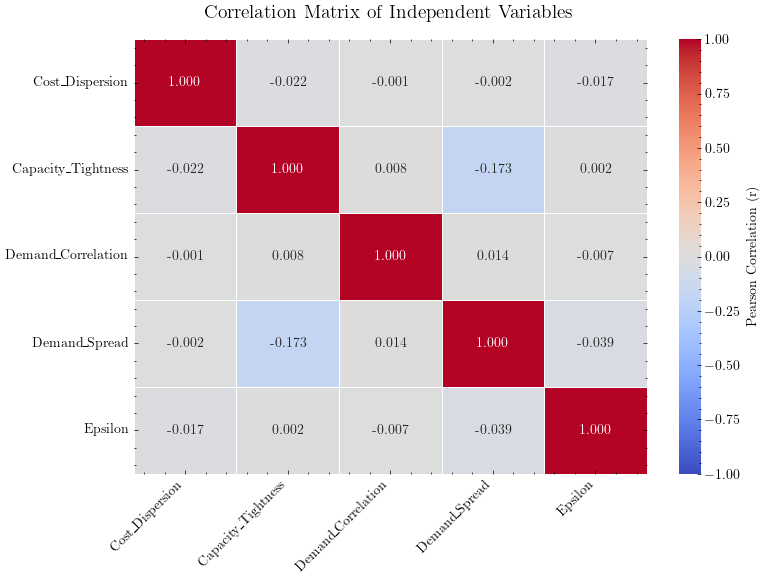

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 4. Correlation Matrix of Independent Variables
# =============================================================================
print("\n" + "="*70)
print("Correlation Matrix of Predictors (Multicollinearity Check)")
print("="*70)

# Select the columns
cols = ['Cost_Dispersion', 'Capacity_Tightness', 'Demand_Correlation', 'Demand_Spread', 'Epsilon']
corr_matrix = df[cols].corr()

# Print the numerical matrix
print(corr_matrix.round(4).to_string())

# Generate a publication-ready Heatmap
plt.figure(figsize=(8, 6))

# We use 'coolwarm' so 0 is white, positive is red, negative is blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".3f", linewidths=0.5, cbar_kws={'label': 'Pearson Correlation (r)'})

plt.title('Correlation Matrix of Independent Variables', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
# plt.savefig('correlation_matrix.pdf', dpi=300) # Uncomment to save for your paper
plt.show()